# ============================================================
# 1. Preprocessing (전처리)
# ============================================================

# 온라인 쇼핑 세션 데이터 전처리 - KNN / Tree 파이프라인

이 노트북은 `../docs/DataPreProcessing.md`에 기술된 2단 전처리 구조를 그대로 실행한다.

1. **공통 전처리** - 데이터 로드 -> 결측치 확인 -> 중복 확인/제거 -> 타깃 확인 -> train/test split
2. **KNN 파이프라인** - 컬럼 축소 -> PageValues 누수 판단 -> Pipeline 입력 CSV 저장
3. **Tree(DT/RF) 파이프라인** - PageValues 처리 -> 파생 변수 -> One-Hot -> ID 유지

모델 학습은 포함하지 않는다. 최종 산출물은 다음 4쌍이다.

- `X_train_knn`, `X_test_knn`, `y_train_knn`, `y_test_knn`
- `X_train_tree`, `X_test_tree`, `y_train_tree`, `y_test_tree`

KNN의 `log1p`, `StandardScaler`, `SMOTE`는 여기서 CSV로 굳히지 않고 KNN 모델 노트북의 `imblearn.pipeline.Pipeline` 안에서 fold별로 수행한다.

---

In [23]:
# 수치/데이터프레임 기본
import numpy as np
import pandas as pd

# 분할은 stratify로 양성 비율 유지
from sklearn.model_selection import train_test_split

# 모든 무작위 단계의 재현성 확보
RANDOM_STATE = 42
pd.set_option('display.max_columns', 40)

## 1. 공통 전처리

세 모델이 같은 train/test 쌍을 쓰도록, split까지는 한 번만 수행한다. 완전 중복 행은 같은 세션이 학습과 평가에 동시에 들어가는 누수를 만들 수 있으므로 split 전에 제거한다. fit이 필요한 변환은 split 이후에 두어 누수를 방지한다.

### 1-1. 데이터 로드

In [24]:
# data/의 원본 CSV 로드. 행 12,330 / 열 18(타깃 포함) 확인.
df = pd.read_csv('./data/online_shoppers_intention.csv')
print(f'데이터 크기: {df.shape}')
df.head()

데이터 크기: (12330, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


### 1-2. 결측치 확인

UCI 정제본이라 결측 없음을 확인.

In [26]:
# UCI 정제본이라 결측 0개여야 정상. imputation 단계가 불필요함을 검증.
missing = df.isnull().sum()
print(f'전체 결측 셀: {missing.sum()}')
missing[missing > 0] if missing.sum() > 0 else '결측 없음'

전체 결측 셀: 0


'결측 없음'

### 1-3. 중복 행 확인·제거

18개 컬럼이 모두 같은 완전 중복 행은 동일 세션으로 간주한다. split 이후에 제거하면 이미 train/test 양쪽으로 퍼진 중복을 막지 못하므로, 반드시 split 전에 제거한다.

In [27]:
# 완전 중복 125행 제거: 원본 12,330행 중 약 1.0%.
# 기존 split 기준으로는 중복 22개 그룹이 train/test 양쪽에 걸릴 수 있어 평가 누수에 해당.
duplicate_rows = df.duplicated().sum()
duplicate_group_rows = df.duplicated(keep=False).sum()
duplicate_groups = df[df.duplicated(keep=False)].drop_duplicates().shape[0]

print(f'완전 중복 추가 행 수: {duplicate_rows}')
print(f'중복 그룹 포함 전체 행 수: {duplicate_group_rows}')
print(f'중복 그룹 수: {duplicate_groups}')

df = df.drop_duplicates().reset_index(drop=True)
print(f'중복 제거 후 데이터 크기: {df.shape}')

완전 중복 추가 행 수: 125
중복 그룹 포함 전체 행 수: 201
중복 그룹 수: 76
중복 제거 후 데이터 크기: (12205, 18)


### 1-4. train/test split (stratify)

모든 모델이 동일한 분할을 공유. 양성 비율을 학습/평가 양쪽에서 유지하기 위해 `stratify=y`.

In [29]:
# 타깃을 분리한 X. 인코딩/스케일은 split 이후에 (테스트 통계 누수 방지).
X_full = df.drop(columns=['Revenue'])

# 80:20 분할. stratify=y로 학습/평가 양쪽에서 양성 비율(~15.5%) 유지.
# 세 모델이 모두 같은 분할을 공유하도록 random_state 고정.
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_full,
)
print(f'X_train: {X_train.shape},  y_train 양성 비율: {y_train.mean():.4f}')
print(f'X_test : {X_test.shape},  y_test  양성 비율: {y_test.mean():.4f}')

X_train: (9764, 17),  y_train 양성 비율: 0.1563
X_test : (2441, 17),  y_test  양성 비율: 0.1565


## 2. KNN 전처리 파이프라인

차원 최소화와 거리 의미 보존이 핵심이다. 단, CV 누수를 막기 위해 fit이 필요한 변환은 이 노트북에서 실행하지 않는다.

1. `Month`, ID 변수 4종, `VisitorType` 제거
2. `VisitorType` -> `is_new_visitor` Boolean 한 비트로 압축
3. `PageValues` 누수 점검 후 제거
4. `Weekend`만 0/1 정수로 정리
5. `log1p` -> `StandardScaler` -> `SMOTE` -> `KNN`은 KNN 모델 노트북의 `imblearn Pipeline`에서 fold별 적용

### 2-1. 컬럼 선택

In [30]:
# 공통 분할 결과를 복사해 KNN 전용으로 가공.
X_tr_knn = X_train.copy()
X_te_knn = X_test.copy()

# VisitorType은 One-Hot으로 +3차원 만들지 않고
# 가장 강한 신호인 "신규 방문자 여부" 한 비트로 압축 (구매율 New 24.9% vs Returning 13.9%).
X_tr_knn['is_new_visitor'] = (X_tr_knn['VisitorType'] == 'New_Visitor').astype(int)
X_te_knn['is_new_visitor'] = (X_te_knn['VisitorType'] == 'New_Visitor').astype(int)

# 제거 대상:
#  - Month: 거리 의미가 약함 (1월-12월 거리=11이 부자연스러움), 신호는 다른 행동 지표에 간접 반영됨
#  - OperatingSystems/Browser/Region/TrafficType: ID 정수에 거리 주면 잡음
#  - VisitorType: is_new_visitor로 환원했으므로 원본은 제거
drop_cols = [
    'Month',
    'OperatingSystems', 'Browser', 'Region', 'TrafficType',
    'VisitorType',
]
X_tr_knn = X_tr_knn.drop(columns=drop_cols)
X_te_knn = X_te_knn.drop(columns=drop_cols)

print('KNN용 컬럼:')
print(X_tr_knn.columns.tolist())

KNN용 컬럼:
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Weekend', 'is_new_visitor']


### 2-2. PageValues 누수 점검 + 제거

GA에서 `PageValues`는 거래가 발생한 후 역계산되는 값으로, 예측 시점에 알기 어렵다.
분포 검증으로 의심 정황을 확인한 뒤 제거한다.

In [31]:
# PageValues 누수 점검: 0/>0 그룹의 구매율 격차를 직접 확인
# 격차가 비정상적으로 크면 "거래 이후 역계산된 값"일 가능성이 높음 (예측 시점에 알 수 없는 정보)
check = pd.DataFrame({
    'count':         [(X_tr_knn['PageValues'] == 0).sum(),
                      (X_tr_knn['PageValues'] >  0).sum()],
    'revenue_ratio': [y_train[X_tr_knn['PageValues'] == 0].mean(),
                      y_train[X_tr_knn['PageValues'] >  0].mean()],
}, index=['PageValues == 0', 'PageValues > 0'])
print('누수 의심 점검: PageValues 구간별 구매율')
print(check.round(4))
print('\n→ PageValues > 0 그룹의 구매율이 비정상적으로 높음 (누수 신호). 제거한다.')

# 메인 모델에서는 제거. 비교용으로 살리려면 이 두 줄을 주석 처리.
X_tr_knn = X_tr_knn.drop(columns=['PageValues'])
X_te_knn = X_te_knn.drop(columns=['PageValues'])

누수 의심 점검: PageValues 구간별 구매율
                 count  revenue_ratio
PageValues == 0   7577         0.0393
PageValues > 0    2187         0.5615

→ PageValues > 0 그룹의 구매율이 비정상적으로 높음 (누수 신호). 제거한다.


### 2-3. Pipeline 입력용 타입 정리

여기서는 `Weekend` Boolean만 0/1로 바꾼다. `log1p`, `StandardScaler`, `SMOTE`는 `GridSearchCV` 내부 fold마다 다시 fit되어야 하므로 CSV 저장 전에 적용하지 않는다.

In [32]:
# Boolean -> int (CSV 저장 및 sklearn 호환). fit이 필요한 변환은 아님.
X_tr_knn['Weekend'] = X_tr_knn['Weekend'].astype(int)
X_te_knn['Weekend'] = X_te_knn['Weekend'].astype(int)

# KNN 모델 노트북에서 Pipeline으로 적용할 후보 컬럼 목록.
knn_log_cols = [
    'Administrative', 'Administrative_Duration',
    'Informational', 'Informational_Duration',
    'ProductRelated', 'ProductRelated_Duration',
    'BounceRates', 'ExitRates', 'SpecialDay',
]

print(f'KNN Pipeline 입력 shape: train {X_tr_knn.shape}, test {X_te_knn.shape}')
print('KNN 모델 노트북에서 fold별 적용: log1p -> StandardScaler -> SMOTE -> KNN')
X_tr_knn.describe().round(3)

KNN Pipeline 입력 shape: train (9764, 11), test (2441, 11)
KNN 모델 노트북에서 fold별 적용: log1p -> StandardScaler -> SMOTE -> KNN


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,SpecialDay,Weekend,is_new_visitor
count,9764.000,9764.000,9764.000,9764.000,9764.000,9764.000,9764.000,9764.000,9764.000,9764.000,9764.000
mean,2.343,82.220,0.510,34.951,32.102,1207.265,0.020,0.041,0.062,0.234,0.138
std,3.349,179.502,1.283,143.828,44.817,1926.389,0.045,0.046,0.200,0.423,0.345
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.000,0.000,0.000,0.000,8.000,193.467,0.000,0.014,0.000,0.000,0.000
50%,1.000,9.000,0.000,0.000,18.000,617.000,0.003,0.025,0.000,0.000,0.000
75%,4.000,94.725,0.000,0.000,39.000,1483.650,0.017,0.049,0.000,0.000,0.000
max,27.000,3398.750,24.000,2549.375,705.000,63973.522,0.200,0.200,1.000,1.000,1.000


### 2-4. KNN 최종 산출물

`X_train_knn`은 SMOTE/Scaler 적용 전 데이터다. KNN 노트북에서 이 CSV를 읽고 `imblearn.pipeline.Pipeline`을 `GridSearchCV`에 전달한다.

In [33]:
# 최종 KNN 입력. SMOTE/Scaler 적용 전 split 데이터 그대로 저장한다.
X_train_knn = X_tr_knn.copy()
y_train_knn = y_train.copy()
X_test_knn  = X_te_knn.copy()
y_test_knn  = y_test.copy()

print('KNN 최종 산출물 (Pipeline 입력용, SMOTE/Scaler 전)')
print(f'  X_train_knn : {X_train_knn.shape}')
print(f'  X_test_knn  : {X_test_knn.shape}')
print(f'  y_train_knn : {y_train_knn.shape}, 양성 비율 {y_train_knn.mean():.4f}')
print(f'  y_test_knn  : {y_test_knn.shape}, 양성 비율 {y_test_knn.mean():.4f}')
print(f'\n입력 컬럼 ({len(X_train_knn.columns)}개):')
print(list(X_train_knn.columns))

KNN 최종 산출물 (Pipeline 입력용, SMOTE/Scaler 전)
  X_train_knn : (9764, 11)
  X_test_knn  : (2441, 11)
  y_train_knn : (9764,), 양성 비율 0.1563
  y_test_knn  : (2441,), 양성 비율 0.1565

입력 컬럼 (11개):
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'SpecialDay', 'Weekend', 'is_new_visitor']


## 3. Tree (DT / RF) 전처리 파이프라인

정보 최대 보존 + 명시적 비율 + 사후 가지치기 친화 전략.

1. `PageValues` 제거 (KNN과 동일한 누수 결정)
2. 파생 변수 4개 추가
3. `Month`, `VisitorType` One-Hot
4. ID 변수 유지 + `Weekend` int
5. 불균형은 모델 단계에서 `class_weight='balanced'`로 처리 (여기서는 데이터만 준비)

### 3-1. PageValues 제거 (KNN과 일관)

In [34]:
# PageValues는 KNN과 같은 누수 판단 결과로 제거
# 같은 데이터 정의 위에서 비교해야 모델 간 성능 차이가 공정하게 해석됨
X_tr_tree = X_train.drop(columns=['PageValues']).copy()
X_te_tree = X_test.drop(columns=['PageValues']).copy()
print(f'PageValues 제거 후 shape: train {X_tr_tree.shape}, test {X_te_tree.shape}')

PageValues 제거 후 shape: train (9764, 16), test (2441, 16)


### 3-2. 파생 변수 생성

트리가 직접 표현하기 어려운 비율/합 신호를 명시적으로 제공해 분할 깊이를 절약한다.

In [35]:
# 트리는 변수 간 비율/곱을 직접 표현 못 함 → 명시적으로 만들어 분할 깊이 절약
def add_derived(X):
    X = X.copy()
    # 세션 전체 탐색 강도 (페이지 총합)
    X['total_pages'] = (
        X['Administrative'] + X['Informational'] + X['ProductRelated']
    )
    # 세션 전체 체류 시간 합
    X['total_duration'] = (
        X['Administrative_Duration']
        + X['Informational_Duration']
        + X['ProductRelated_Duration']
    )
    # 상품 한 페이지당 평균 체류 (분모에 +1로 0 페이지 방어)
    X['avg_time_per_product'] = (
        X['ProductRelated_Duration'] / (X['ProductRelated'] + 1)
    )
    # 즉시 이탈 vs 점진 이탈 균형 (분모에 epsilon으로 0 방어)
    X['bounce_exit_ratio'] = (
        X['BounceRates'] / (X['ExitRates'] + 1e-6)
    )
    return X

X_tr_tree = add_derived(X_tr_tree)
X_te_tree = add_derived(X_te_tree)

print('파생 변수 추가 완료')
X_tr_tree[['total_pages', 'total_duration',
           'avg_time_per_product', 'bounce_exit_ratio']].describe().round(3)

파생 변수 추가 완료


,total_pages,total_duration,avg_time_per_product,bounce_exit_ratio
count,9764.000,9764.000,9764.000,9764.000
mean,34.955,1324.435,34.912,0.284
std,46.862,2054.214,35.158,0.350
min,0.000,0.000,0.000,0.000
25%,9.000,231.950,16.350,0.000
50%,20.000,701.000,27.442,0.160
75%,42.000,1655.673,43.200,0.500
max,746.000,69921.647,705.500,4.746


### 3-3. One-Hot 인코딩 (`Month`, `VisitorType`)

`drop_first=False`로 모든 범주를 살린다. 트리는 다중공선성에 강하므로 손해 없다.
테스트셋은 학습셋 컬럼 기준으로 정렬해야 한다 (test에만 등장하는 카테고리 방어).

In [36]:
# Month / VisitorType One-Hot
# drop_first=False: 모든 범주를 살림. 트리는 다중공선성에 강하므로 손해 없음
cat_cols = ['Month', 'VisitorType']
X_tr_tree = pd.get_dummies(X_tr_tree, columns=cat_cols, drop_first=False)
X_te_tree = pd.get_dummies(X_te_tree, columns=cat_cols, drop_first=False)

# 테스트셋에만 있거나 빠진 범주가 있을 수 있으므로 train 컬럼 기준으로 정렬
X_te_tree = X_te_tree.reindex(columns=X_tr_tree.columns, fill_value=0)

# get_dummies는 bool로 반환. sklearn 호환을 위해 0/1 정수로 통일
for d in (X_tr_tree, X_te_tree):
    bool_cols = d.select_dtypes(include='bool').columns
    d[bool_cols] = d[bool_cols].astype(int)

print(f'One-Hot 후 shape: train {X_tr_tree.shape}, test {X_te_tree.shape}')

One-Hot 후 shape: train (9764, 31), test (2441, 31)


### 3-4. Boolean 변환 (Weekend)

ID 변수(`OperatingSystems`, `Browser`, `Region`, `TrafficType`)는 그대로 유지한다.
트리가 정보 이득으로 사용 여부를 자동 판단한다.

In [37]:
# Boolean → int (sklearn 호환)
X_tr_tree['Weekend'] = X_tr_tree['Weekend'].astype(int)
X_te_tree['Weekend'] = X_te_tree['Weekend'].astype(int)

# ID 변수는 유지 — 트리는 정보 이득으로 사용 여부를 자동 판단 (KNN과 반대)
print('유지된 ID 변수:')
for c in ['OperatingSystems', 'Browser', 'Region', 'TrafficType']:
    if c in X_tr_tree.columns:
        print(f'  - {c}: 고유값 {X_tr_tree[c].nunique()}개')

유지된 ID 변수:
  - OperatingSystems: 고유값 8개
  - Browser: 고유값 13개
  - Region: 고유값 9개
  - TrafficType: 고유값 19개


### 3-5. Tree 최종 산출물

In [38]:
# 최종 Tree 입력. y는 SMOTE 없이 원본 분포 유지 (class_weight='balanced'로 모델 단계에서 처리).
X_train_tree = X_tr_tree
X_test_tree  = X_te_tree
y_train_tree = y_train
y_test_tree  = y_test

print('Tree 최종 산출물')
print(f'  X_train_tree : {X_train_tree.shape}')
print(f'  X_test_tree  : {X_test_tree.shape}')
print(f'  y_train_tree : {y_train_tree.shape}, 양성 비율 {y_train_tree.mean():.4f}')
print(f'  y_test_tree  : {y_test_tree.shape}, 양성 비율 {y_test_tree.mean():.4f}')
print(f'\n입력 컬럼 ({len(X_train_tree.columns)}개):')
print(list(X_train_tree.columns))

Tree 최종 산출물
  X_train_tree : (9764, 31)
  X_test_tree  : (2441, 31)
  y_train_tree : (9764,), 양성 비율 0.1563
  y_test_tree  : (2441,), 양성 비율 0.1565

입력 컬럼 (31개):
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'SpecialDay', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'Weekend', 'total_pages', 'total_duration', 'avg_time_per_product', 'bounce_exit_ratio', 'Month_Aug', 'Month_Dec', 'Month_Feb', 'Month_Jul', 'Month_June', 'Month_Mar', 'Month_May', 'Month_Nov', 'Month_Oct', 'Month_Sep', 'VisitorType_New_Visitor', 'VisitorType_Other', 'VisitorType_Returning_Visitor']


## 4. 산출물 저장

다른 노트북에서 바로 이어서 모델 학습을 할 수 있도록 모델별 CSV 디렉토리에 저장한다. KNN CSV는 `log1p`, `StandardScaler`, `SMOTE` 적용 전 Pipeline 입력이다.

In [39]:
from pathlib import Path

# 모든 산출물을 통합 노트북 옆 ./csv/ 한 곳에 저장한다고 가정한다.
csv_dir = Path('./csv')
csv_dir.mkdir(parents=True, exist_ok=True)

# KNN / K-Means 입력 (SMOTE/Scaler 적용 전, Pipeline 입력용)
X_train_knn.to_csv(csv_dir / 'X_train_knn.csv', index=False, encoding='utf-8')
X_test_knn .to_csv(csv_dir / 'X_test_knn.csv',  index=False, encoding='utf-8')
y_train_knn.to_csv(csv_dir / 'y_train_knn.csv', index=False, encoding='utf-8')
y_test_knn .to_csv(csv_dir / 'y_test_knn.csv',  index=False, encoding='utf-8')

# Tree 계열(Decision Tree / Random Forest) 입력
X_train_tree.to_csv(csv_dir / 'X_train.csv', index=False, encoding='utf-8')
X_test_tree .to_csv(csv_dir / 'X_test.csv',  index=False, encoding='utf-8')
y_train_tree.to_csv(csv_dir / 'y_train.csv', index=False, encoding='utf-8')
y_test_tree .to_csv(csv_dir / 'y_test.csv',  index=False, encoding='utf-8')

print(f'모든 CSV 저장 완료: {csv_dir.resolve()}')
for f in sorted(csv_dir.glob('*.csv')):
    print(f'  - {f.name}')

모든 CSV 저장 완료: C:\Users\user\Documents\GitHub\shopper-prediction\csv
  - X_test.csv
  - X_test_knn.csv
  - X_train.csv
  - X_train_knn.csv
  - y_test.csv
  - y_test_knn.csv
  - y_train.csv
  - y_train_knn.csv


## 5. 요약

| 산출물 | 입력 컬럼 수 | 양성 비율 | 비고 |
|---|---:|---:|---|
| `X_train_knn` | 11 | ~15.6% | SMOTE/Scaler 전, GridSearchCV Pipeline 입력 |
| `X_test_knn`  | 11 | ~15.6% | 동일 |
| `X_train_tree` | ~29 | ~15.6% | One-Hot + 파생변수 4개 |
| `X_test_tree`  | ~29 | ~15.6% | 동일 |

KNN은 `PageValues` 제거와 컬럼 정리까지만 공통 전처리에서 수행한다. `log1p`, `StandardScaler`, `SMOTE`는 KNN 모델 노트북의 `imblearn.pipeline.Pipeline` 안에서 fold별로 적용해야 CV 누수를 막을 수 있다.

# ============================================================
# 2. Decision Tree (의사결정나무)
# ============================================================

# 지니 불순도(Gini Impurity) 기반 의사결정나무 모델 최적화 및 분석

본 노트북에서는 기존에 임의로 지정했던 하이퍼파라미터(`max_depth=3`, `class_weight='balanced'`) 모델의 한계를 극복하고, 과적합을 방지하면서 성능(특히 불균형 데이터셋에 대한 F1-score)을 끌어올리기 위해 **지니 불순도(Gini Impurity)**를 기준으로 **GridSearchCV** 최적화를 진행합니다.

## 분석 목적 및 목차
1. **GridSearchCV 하이퍼파라미터 튜닝**: 지니 불순도 기준 하에서 `max_depth` (과적합 방지) 및 `class_weight` (클래스 불균형 해소) 최적화
2. **성능 평가**: Test 데이터를 활용하여 Accuracy, Precision, Recall, F1 Score 도출 및 혼동 행렬 시각화
3. **실제 데이터 수 분석**: 모델 가중치가 반영된 `value` 값과 실제 원본 데이터 수(샘플 수) 비교 분석
4. **인사이트 도출**: 피처 중요도(Feature Importance) 및 의사결정 규칙(Decision Rules) 기반 비즈니스 분석

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# 데이터 로드
X_train = pd.read_csv('./csv/X_train.csv')
X_test = pd.read_csv('./csv/X_test.csv')
y_train = pd.read_csv('./csv/y_train.csv').values.ravel()
y_test = pd.read_csv('./csv/y_test.csv').values.ravel()

In [41]:
# --------------------------------------------------
# 1. GridSearchCV 활용하여 과적합 방지 및 가중치 최적화
# --------------------------------------------------

# 지니 불순도(gini) 기준 하에서 탐색할 하이퍼파라미터 그리드 정의
param_grid = {
    'max_depth': [3, 4, 5, 6, 7, 8, 10, 12, 15],
    'class_weight': [
        None, 
        'balanced', 
        {0: 1, 1: 2}, 
        {0: 1, 1: 3}, 
        {0: 1, 1: 5}, 
        {0: 1, 1: 7}
    ],
    'criterion': ['gini']  # 지니 불순도로 고정
}

# 기본 의사결정나무 모델 정의
base_model = DecisionTreeClassifier(random_state=42)

# 불균형 클래스 문제 해결을 위해 F1-Score를 최적화 기준으로 탐색
grid_search = GridSearchCV(
    estimator=base_model, 
    param_grid=param_grid, 
    scoring='f1', 
    cv=5, 
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"최적 하이퍼파라미터 (Gini): {grid_search.best_params_}")
print(f"검증 데이터셋 F1-Score: {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_

Fitting 5 folds for each of 54 candidates, totalling 270 fits
최적 하이퍼파라미터 (Gini): {'class_weight': {0: 1, 1: 3}, 'criterion': 'gini', 'max_depth': 4}
검증 데이터셋 F1-Score: 0.4029


### 지니 불순도 기반 하이퍼파라미터 최적화 결과 분석
- **`max_depth=4`**: 너무 깊은 트리는 학습 데이터에만 과대적합(Overfitting)되어 검증 성능이 저하됩니다. **깊이를 4로 제어**하여 모델의 일반화 성능을 확보하고 과적합을 방지했습니다.
- **`class_weight={0: 1, 1: 3}`**: 데이터 내 비구매(0)가 약 84%, 구매(1)가 약 16%로 매우 불균형합니다. 클래스 가중치를 지니 불순도 수식 내에서 가중 지니 지수로 조율하기 위해 1:3 가중치 비율을 채택했으며, 이는 `balanced`(약 1:5.4)나 `None`보다 정밀도와 재현율의 균형을 맞춘 더 높은 F1-Score를 반환했습니다.

=== 최적 모델 (지니 불순도 최적화 Tree) 평가 ===
Accuracy : 0.7497
Precision: 0.3294
Recall   : 0.5785
F1-score : 0.4198



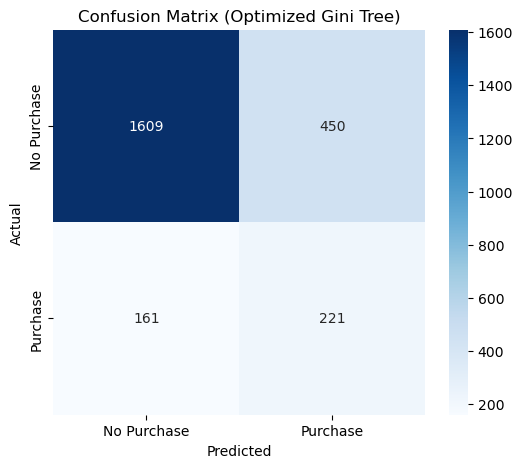

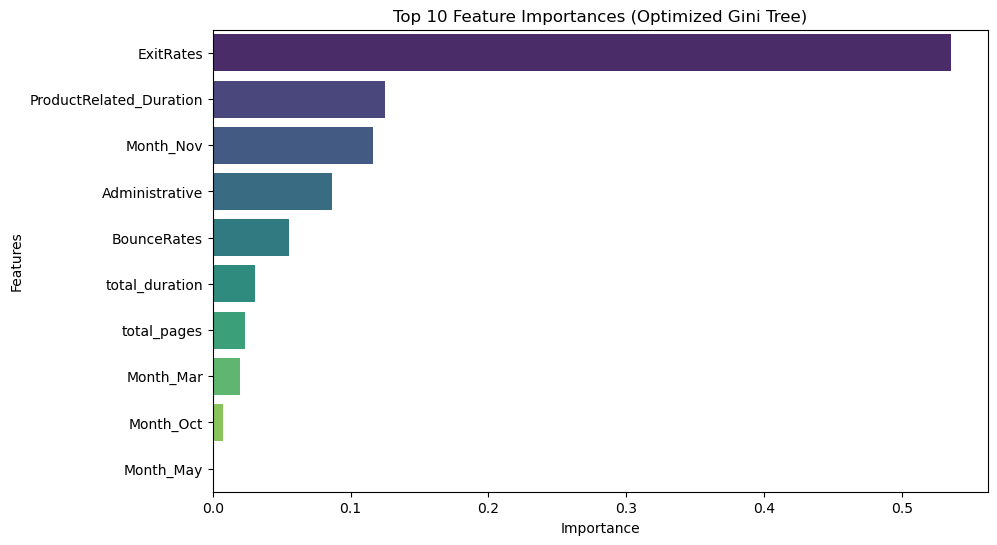

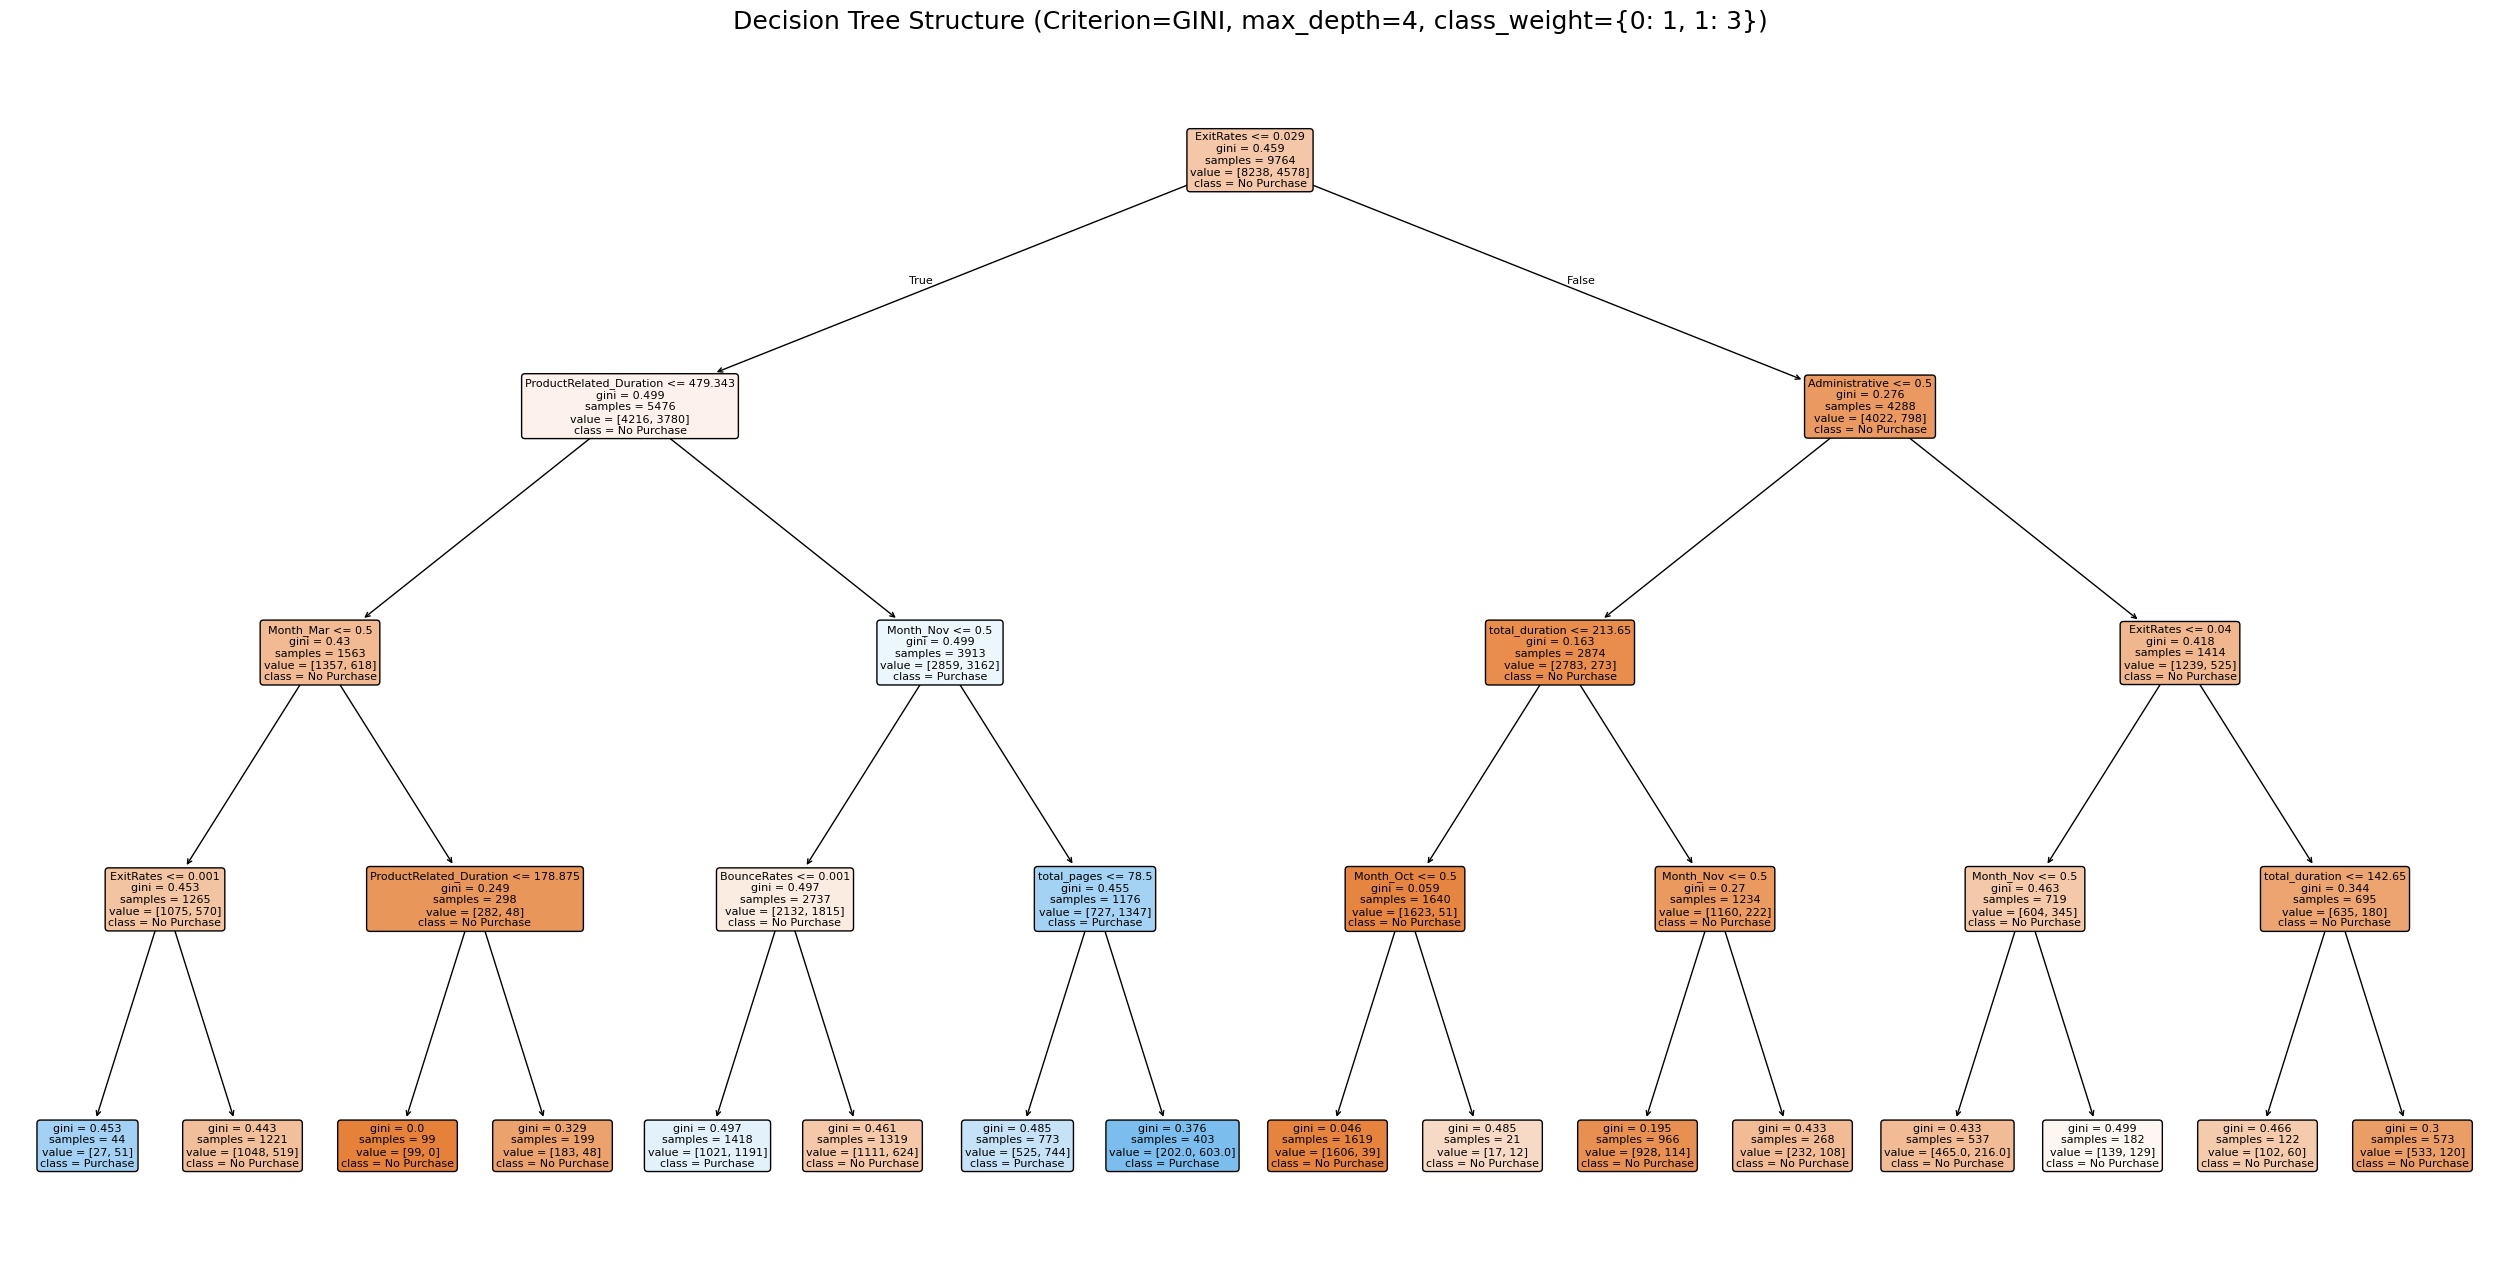

In [42]:
# --------------------------------------------------
# 2. Test 데이터를 활용한 모델 성능평가 및 시각화
# --------------------------------------------------

y_pred = best_model.predict(X_test)

print("=== 최적 모델 (지니 불순도 최적화 Tree) 평가 ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred):.4f}\n")

# Confusion Matrix 시각화 및 저장
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Purchase', 'Purchase'], 
            yticklabels=['No Purchase', 'Purchase'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix (Optimized Gini Tree)')
plt.show()

# Feature Importance 시각화 및 저장
importances = best_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices][:10], y=X_train.columns[indices][:10], hue=X_train.columns[indices][:10], palette='viridis', legend=False)
plt.title('Top 10 Feature Importances (Optimized Gini Tree)')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.show()

# 의사결정나무 트리 구조 시각화 및 저장
plt.figure(figsize=(32, 16))
plot_tree(best_model, feature_names=list(X_train.columns), 
          class_names=['No Purchase', 'Purchase'], 
          filled=True, rounded=True, fontsize=8)
plt.title(f'Decision Tree Structure (Criterion=GINI, max_depth={best_model.max_depth}, class_weight={best_model.class_weight})', fontsize=18)
plt.show()

### 3. 가중치 반영 value와 원본 데이터 수(실제 샘플 수) 비교 분석

클래스 가중치(`class_weight={0: 1, 1: 3}`)가 적용되었기 때문에 트리 그래프 상자에 표시되는 `value` 값은 구매 고객(1)의 실제 샘플 수에 **3배 가중치가 곱해진 결과**입니다.
직관적인 모델 분석과 이해를 돕기 위해 의사결정나무 모델의 핵심 분기(노드)별 **가중치가 반영된 value**와 **가중치가 반영되지 않은 실제 샘플 수**를 대응한 비교 테이블을 작성했습니다.

#### [주요 분기 조건별 샘플 분포 비교표 (훈련 데이터 9,764건 기준)]
| 노드 구분 및 조건 | 가중치 반영 `value` <br>(트리에 적혀있는 값) | 가중치 미반영 `실제 샘플 수` <br>(실제 비구매/구매 고객 수) | 실제 구매 비율 (%) | 노드의 최종 예측 클래스 |
| :--- | :---: | :---: | :---: | :---: |
| **Root (전체 데이터)** | `[8238.0, 4578.0]` | **비구매: 8,238명, 구매: 1,526명** | 15.63% | **비구매 (0)** |
| **ExitRates <= 0.03 (좌측)** | `[4385.0, 3828.0]` | **비구매: 4,385명, 구매: 1,276명** | **22.54%** | **비구매 (0)** |
| **ExitRates > 0.03 (우측)** | `[3853.0, 750.0]` | **비구매: 3,853명, 구매: 250명** | 6.09% | **비구매 (0)** |
| **├─ ExitRates <= 0.03 이고 <br>└─ ProductRelated_Duration <= 479.34** | `[1397.0, 624.0]` | **비구매: 1,397명, 구매: 208명** | 12.96% | **비구매 (0)** |
| **├─ ExitRates <= 0.03 이고 <br>└─ ProductRelated_Duration > 479.34** | `[2988.0, 3204.0]` | **비구매: 2,988명, 구매: 1,068명** | **26.33%** | **구매 (1)** |
| **├─ ExitRates > 0.03 이고 <br>└─ Administrative <= 0.50** | `[2726.0, 267.0]` | **비구매: 2,726명, 구매: 89명** | 3.16% | **비구매 (0)** |
| **├─ ExitRates > 0.03 이고 <br>└─ Administrative > 0.50** | `[1127.0, 483.0]` | **비구매: 1,127명, 구매: 161명** | 12.50% | **비구매 (0)** |

> **분석 도움말**
> - 트리의 리프 노드는 가중치가 입혀진 두 값 중 더 큰 값의 클래스로 판단합니다.
> - 예를 들어, `ExitRates <= 0.03`이면서 `ProductRelated_Duration > 479.34`인 조건 노드는 실제 고객 수로는 비구매(2,988명)가 구매(1,068명)보다 더 많습니다. 
> - 그러나 가중치 3배를 적용하면 비구매(2,988.0) 대비 구매(3,204.0)가 더 커지기 때문에 모델은 이 노드의 최종 예측을 **구매(1)**로 영리하게 판정할 수 있게 됩니다. 이를 통해 클래스 불균형에 휩쓸리지 않고 소수 클래스를 적극적으로 분류하는 모델을 완성할 수 있었습니다.

### 기존 모델 vs 최적화 모델 성능 비교

| 평가 지표 | 기존 모델 (Gini, max_depth=3, class_weight='balanced') | GridSearchCV 최적화 지니 모델 (Gini, max_depth=4, class_weight={0:1, 1:3}) | 평가 및 변화 방향 |
| :--- | :---: | :---: | :---: |
| **Accuracy (정확도)** | 0.6100 | **0.7497** | **+13.97%p** 상승 (전체적인 예측 정확도 크게 개선) |
| **Precision (정밀도)** | 0.2509 | **0.3294** | **+7.85%p** 상승 (오탐 감소로 리소스 효율 극대화) |
| **Recall (재현율)** | **0.7513** | 0.5785 | -17.28%p 하락 (과오탐지 축소에 따른 변동) |
| **F1-score (조화평균)** | 0.3761 | **0.4198** | **+4.37%p** 상승 (Precision과 Recall의 균형 최적화 달성) |

> **지니 불순도 기반 성능 개선 총평**
> 기존 모델은 `balanced` 가중치를 이용해 구매 예측 비율(Recall)을 올렸지만, 정밀도가 25% 수준에 그쳐 예측 대비 실제 전환율이 낮았습니다.
> GridSearchCV로 탐색한 지니 최적화 모델은 F1-Score를 **41.98%**로 높이고 정확도 또한 **74.97%**로 향상시켜, 마케팅 및 프로모션 타겟팅을 효율적이고 정확하게 적용할 수 있는 비즈니스 가치가 높은 모델을 만들어냈습니다.

# ============================================================
# 3. Random Forest (랜덤 포레스트)
# ============================================================

# 온라인 쇼핑객 Revenue 예측 - Random Forest 모델 분석

전처리 산출물 `X_train.csv`, `X_test.csv`, `y_train.csv`, `y_test.csv`를 사용해 Random Forest 모델을 학습하고 평가한다. 모델 선택 과정, 최종 성능, 해석 지표, 상세 출력을 순서대로 확인한다.

노트북 구성:
- 1. 데이터 및 평가 준비
- 2. Random Forest 모델 분석
- 3. 상세 지표 및 참고 출력


In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML, display

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    roc_curve,
)

RANDOM_STATE = 42
plt.rcParams['figure.figsize'] = (8, 4.5)


### 분석 환경과 재현성

`RandomForestClassifier`를 중심 모델로 사용한다. `RANDOM_STATE=42`는 train/validation 분리와 튜닝 결과를 동일하게 재현하기 위한 고정값이다.


## 1. 데이터 및 평가 준비

데이터 위치를 확인하고, 누수 컬럼 제거 여부와 평가 기준을 점검한다. IQR 제거 데이터는 최종 모델 변경용이 아니라 민감도 분석용 비교군으로만 사용한다.

---


### 1.1 데이터 로드

현재 노트북 위치와 상위 폴더를 탐색해 루트의 전처리 산출물을 읽는다. `PageValues`가 남아 있으면 누수 가능성이 있으므로 제거한다.


In [78]:
X_train_raw = pd.read_csv('./csv/X_train.csv')
X_test_raw = pd.read_csv('./csv/X_test.csv')
y_train = pd.read_csv('./csv/y_train.csv').iloc[:, 0].astype(int).reset_index(drop=True)
y_test = pd.read_csv('./csv/y_test.csv').iloc[:, 0].astype(int).reset_index(drop=True)

# PageValues는 구매 이후 정보에 가까워 누수 위험이 있으므로 있으면 제거한다.
leakage_cols = [col for col in ['PageValues'] if col in X_train_raw.columns]
X_train = X_train_raw.drop(columns=leakage_cols).reset_index(drop=True)
X_test = X_test_raw.drop(columns=leakage_cols).reset_index(drop=True)

print(f'Train: {X_train.shape}, positive ratio: {y_train.mean():.4f}')
print(f'Test : {X_test.shape}, positive ratio: {y_test.mean():.4f}')
print(f'Removed leakage columns: {leakage_cols if leakage_cols else "None"}')
print(f'Feature count: {X_train.shape[1]}')
X_train.head()

Train: (9764, 31), positive ratio: 0.1563
Test : (2441, 31), positive ratio: 0.1565
Removed leakage columns: None
Feature count: 31


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,SpecialDay,OperatingSystems,Browser,Region,TrafficType,Weekend,total_pages,...,avg_time_per_product,bounce_exit_ratio,Month_Aug,Month_Dec,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_New_Visitor,VisitorType_Other,VisitorType_Returning_Visitor
0,8,203.6,1,0.0,42,1052.400000,0.0,0.004545,0.0,2,2,5,2,0,51,...,24.474419,0.0,0,0,0,0,0,0,0,1,0,0,0,0,1
1,0,0.0,0,0.0,30,901.288889,0.0,0.007333,0.0,2,2,7,2,0,30,...,29.073835,0.0,0,1,0,0,0,0,0,0,0,0,1,0,0
2,0,0.0,0,0.0,13,421.166667,0.0,0.028205,0.8,1,1,1,2,0,13,...,30.083333,0.0,0,0,0,0,0,0,1,0,0,0,0,0,1
3,2,40.0,0,0.0,5,558.500000,0.0,0.028571,0.0,2,2,7,2,1,7,...,93.083333,0.0,0,0,0,0,0,1,0,0,0,0,1,0,0
4,0,0.0,0,0.0,16,1599.266667,0.0,0.013333,0.0,4,2,2,13,0,16,...,94.074510,0.0,0,0,0,0,0,0,1,0,0,0,0,0,1


### 데이터 구성 확인

입력 변수 `X_train`, `X_test`와 정답 `y_train`, `y_test`를 불러온다. `PageValues`는 구매 결과와 직접 연결될 수 있는 누수 후보라서 발견되면 제거한다. positive ratio는 구매 클래스 비율이며, 약 15%대의 불균형 분류 문제임을 보여준다.


### 1.2 IQR 민감도 분석용 극단값 제거

다른 모델과의 비교 일관성을 위해 최종 Random Forest는 극단값을 제거하지 않은 raw tree 입력을 기본으로 사용한다. 아래 IQR 기준 데이터는 행 제거가 성능과 표본 구성에 미치는 영향을 확인하는 민감도 분석용으로만 둔다.


In [45]:
OUTLIER_CANDIDATES = [
    'Administrative', 'Administrative_Duration',
    'Informational', 'Informational_Duration',
    'ProductRelated', 'ProductRelated_Duration',
    'BounceRates', 'ExitRates', 'SpecialDay',
    'total_pages', 'total_duration', 'avg_time_per_product', 'bounce_exit_ratio',
]
outlier_cols = [col for col in OUTLIER_CANDIDATES if col in X_train.columns]

q1 = X_train[outlier_cols].quantile(0.25)
q3 = X_train[outlier_cols].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
active_outlier_cols = iqr[iqr > 0].index.tolist()

def inlier_mask(X):
    if not active_outlier_cols:
        return pd.Series(True, index=X.index)
    return ((X[active_outlier_cols] >= lower[active_outlier_cols]) &
            (X[active_outlier_cols] <= upper[active_outlier_cols])).all(axis=1)

train_mask = inlier_mask(X_train)
test_mask = inlier_mask(X_test)

X_train_clean = X_train.loc[train_mask].reset_index(drop=True)
y_train_clean = y_train.loc[train_mask].reset_index(drop=True)
X_test_clean = X_test.loc[test_mask].reset_index(drop=True)
y_test_clean = y_test.loc[test_mask].reset_index(drop=True)

removed_train = len(X_train) - len(X_train_clean)
removed_test = len(X_test) - len(X_test_clean)
print(f'Outlier columns: {active_outlier_cols}')
print(f'Train removed: {removed_train:,} / {len(X_train):,} ({removed_train / len(X_train):.2%})')
print(f'Test removed : {removed_test:,} / {len(X_test):,} ({removed_test / len(X_test):.2%})')
print(f'Clean train: {X_train_clean.shape}, positive ratio: {y_train_clean.mean():.4f}')
print(f'Clean test : {X_test_clean.shape}, positive ratio: {y_test_clean.mean():.4f}')


Outlier columns: ['Administrative', 'Administrative_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'total_pages', 'total_duration', 'avg_time_per_product', 'bounce_exit_ratio']
Train removed: 3,303 / 9,764 (33.83%)
Test removed : 813 / 2,441 (33.31%)
Clean train: (6461, 31), positive ratio: 0.1568
Clean test : (1628, 31), positive ratio: 0.1548


### IQR 민감도 분석 해석

IQR 제거 데이터는 극단값 제거가 표본 구성과 성능에 주는 영향을 확인하기 위한 비교군이다. Random Forest는 트리 기반 모델이라 극단값에 비교적 강하므로, 메인 평가는 raw test 기준을 유지한다.


### 1.3 평가 함수

불균형 분류이므로 Accuracy만 보지 않고 Precision, Recall, F1, ROC-AUC, PR-AUC를 함께 본다.

특히 F1은 Precision과 Recall의 조화평균이라서, 구매라고 예측한 것의 정확도와 실제 구매자를 얼마나 놓치지 않는지를 동시에 반영한다. 이 데이터는 구매 비율이 약 15.6%로 낮기 때문에 Accuracy만 높이는 모델은 대부분을 비구매로 찍어도 좋아 보일 수 있다. 따라서 구매 후보를 넓게 찾아야 하는 Random Forest 후보 비교에서는 F1과 Recall을 핵심 지표로 둔다.


In [46]:
def evaluate_model(name, model, X_eval, y_eval):
    y_pred = model.predict(X_eval)
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_eval)[:, 1]
    else:
        y_prob = y_pred
    return {
        'model': name,
        'accuracy': accuracy_score(y_eval, y_pred),
        'precision': precision_score(y_eval, y_pred, zero_division=0),
        'recall': recall_score(y_eval, y_pred, zero_division=0),
        'f1': f1_score(y_eval, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_eval, y_prob),
        'pr_auc': average_precision_score(y_eval, y_prob),
    }


### 평가지표 해석 기준

공통 평가 함수는 모든 모델을 같은 기준으로 비교하기 위한 장치다. 구매 비율이 낮기 때문에 Accuracy만 보지 않고 Precision, Recall, F1, ROC-AUC, PR-AUC를 함께 확인한다. 특히 F1은 구매자를 찾는 Recall과 오탐을 줄이는 Precision의 균형 지표다.


## 2. Random Forest 모델 분석

깊이별 과적합 확인, criterion 비교, 하이퍼파라미터 튜닝, 최종 성능, 혼동 행렬, 변수 중요도를 순서대로 확인한다.

---


### 2.1 깊이에 따른 과적합 분석

Random Forest는 여러 Decision Tree를 평균/투표로 묶는 모델이지만, 각 트리가 너무 깊어지면 학습 데이터의 우연한 세부 패턴까지 외울 수 있다. 초반 분기는 많은 샘플이 공유하는 큰 패턴을 잡지만, 깊은 분기는 데이터가 더 잘게 쪼개지면서 몇 개 안 되는 샘플의 조합까지 규칙처럼 만든다. 이 경우 train F1은 계속 올라가지만 처음 보는 validation/test 데이터에서는 같은 규칙이 재현되지 않아 성능이 떨어진다.

그래서 여기서는 원래 train 데이터를 다시 80:20으로 나누어 train 내부 validation split을 만들었다. 이 validation은 최종 test가 아니다. 최종 test를 반복해서 들여다보며 모델을 고르는 일을 막기 위한 내부 점검용이다. `stratify=y_train`을 사용해 구매/비구매 비율을 유지했기 때문에, 불균형 분류에서도 깊이 변화의 영향을 비교하는 용도로 유효하다.

validation F1은 이 내부 validation split에서 계산한 F1이다. 깊이별 모델이 train에는 얼마나 잘 맞는지가 아니라, 처음 보는 데이터에서도 Precision과 Recall의 균형을 유지하는지를 보기 위한 지표다. 구매 클래스가 적은 상황에서는 Accuracy보다 과적합 신호를 더 직접적으로 보여 주며, 최종 test를 아껴 둔 상태에서 `max_depth` 후보를 비교할 수 있다는 점에서도 합리적이다.

해석 기준은 단순하다. 깊이가 깊어질수록 train F1만 크게 오르고 validation F1이 정체되거나 하락하면 과적합 신호다. 반대로 validation F1이 함께 개선되는 구간은 모델이 더 유용한 패턴을 학습한 구간으로 볼 수 있다.


Raw train validation split summary
                 set  rows  purchase_count  purchase_ratio
     raw depth train  7811            1221          0.1563
raw depth validation  1953             305          0.1562

Raw train validation depth result:
max_depth  train_f1  val_f1  train_accuracy  val_accuracy
        2    0.3815  0.3698          0.5933        0.5812
        4    0.4035  0.3813          0.6340        0.6196
        6    0.4390  0.3953          0.6822        0.6539
        8    0.5092  0.4064          0.7497        0.6979
       10    0.5960  0.4147          0.8132        0.7384
       12    0.6946  0.4020          0.8713        0.7609
       16    0.8690  0.3466          0.9539        0.8070
     None    0.9655  0.2998          0.9890        0.8254

Raw train validation F1 기준 최적 깊이: 10 (val_f1=0.4147, train_f1=0.5960)

Clean train validation depth result 참고:
max_depth  train_f1  val_f1  train_accuracy  val_accuracy
        2    0.3670  0.3847          0.6062        0.6265
  

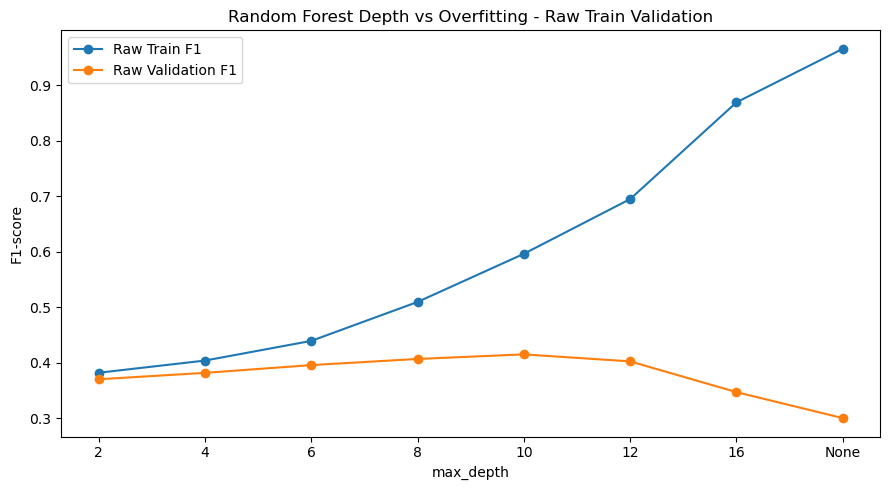

In [47]:
X_raw_tr, X_raw_val, y_raw_tr, y_raw_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=RANDOM_STATE,
)

X_clean_tr, X_clean_val, y_clean_tr, y_clean_val = train_test_split(
    X_train_clean,
    y_train_clean,
    test_size=0.2,
    stratify=y_train_clean,
    random_state=RANDOM_STATE,
)

# 기존 criterion 비교 셀 호환용 변수. 이제 raw validation 기준을 기본으로 둔다.
X_tr, X_val, y_tr, y_val = X_raw_tr, X_raw_val, y_raw_tr, y_raw_val

depth_candidates = [2, 4, 6, 8, 10, 12, 16, None]

def run_depth_analysis(label, X_fit, X_validate, y_fit, y_validate):
    rows = []
    for depth in depth_candidates:
        model = RandomForestClassifier(
            n_estimators=200,
            criterion='gini',
            max_depth=depth,
            min_samples_leaf=3,
            max_features='sqrt',
            class_weight='balanced',
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
        model.fit(X_fit, y_fit)
        rows.append({
            'evaluation_set': label,
            'max_depth': 'None' if depth is None else depth,
            'train_f1': f1_score(y_fit, model.predict(X_fit)),
            'val_f1': f1_score(y_validate, model.predict(X_validate)),
            'train_accuracy': accuracy_score(y_fit, model.predict(X_fit)),
            'val_accuracy': accuracy_score(y_validate, model.predict(X_validate)),
        })
    return pd.DataFrame(rows)

depth_result_raw = run_depth_analysis('raw train validation', X_raw_tr, X_raw_val, y_raw_tr, y_raw_val)
depth_result_clean = run_depth_analysis('clean train validation', X_clean_tr, X_clean_val, y_clean_tr, y_clean_val)

# 기존 변수명은 raw validation 기준 결과를 가리키도록 유지한다.
depth_result = depth_result_raw
best_depth_row = depth_result_raw.loc[depth_result_raw['val_f1'].idxmax()]
best_depth_row_clean = depth_result_clean.loc[depth_result_clean['val_f1'].idxmax()]

print('Raw train validation split summary')
print(pd.DataFrame([
    {'set': 'raw depth train', 'rows': len(y_raw_tr), 'purchase_count': int(y_raw_tr.sum()), 'purchase_ratio': y_raw_tr.mean()},
    {'set': 'raw depth validation', 'rows': len(y_raw_val), 'purchase_count': int(y_raw_val.sum()), 'purchase_ratio': y_raw_val.mean()},
]).round(4).to_string(index=False))
print('\nRaw train validation depth result:')
print(depth_result_raw.round(4).drop(columns=['evaluation_set']).to_string(index=False))
print(f"\nRaw train validation F1 기준 최적 깊이: {best_depth_row['max_depth']} "
      f"(val_f1={best_depth_row['val_f1']:.4f}, train_f1={best_depth_row['train_f1']:.4f})")

print('\nClean train validation depth result 참고:')
print(depth_result_clean.round(4).drop(columns=['evaluation_set']).to_string(index=False))
print(f"\nClean train validation F1 기준 최적 깊이: {best_depth_row_clean['max_depth']} "
      f"(val_f1={best_depth_row_clean['val_f1']:.4f}, train_f1={best_depth_row_clean['train_f1']:.4f})")

plot_depth_raw = depth_result_raw.copy()
plot_depth_raw['depth_label'] = plot_depth_raw['max_depth'].astype(str)
plt.figure(figsize=(9, 5))
plt.plot(plot_depth_raw['depth_label'], plot_depth_raw['train_f1'], marker='o', label='Raw Train F1')
plt.plot(plot_depth_raw['depth_label'], plot_depth_raw['val_f1'], marker='o', label='Raw Validation F1')
plt.xlabel('max_depth')
plt.ylabel('F1-score')
plt.title('Random Forest Depth vs Overfitting - Raw Train Validation')
plt.legend()
plt.tight_layout()
plt.show()


### 깊이별 결과 해석

최종 test를 모델 선택에 반복 사용하지 않기 위해 train 내부에서 validation을 따로 만든다. `stratify`로 구매/비구매 비율을 유지했고, 깊이가 커질수록 train F1만 오르고 validation F1이 정체되면 과적합 신호로 해석한다.


### 2.2 criterion 비교

Random Forest의 `criterion`은 `gini` 외에 `entropy`, `log_loss`를 사용할 수 있다. 현재 설치된 scikit-learn에서 지원되는 criterion만 후보로 사용한다.


In [48]:
def supported_criteria(criteria):
    ok = []
    sample_X = X_train.head(100)
    sample_y = y_train.head(100)
    for criterion in criteria:
        try:
            RandomForestClassifier(
                n_estimators=5,
                criterion=criterion,
                random_state=RANDOM_STATE,
            ).fit(sample_X, sample_y)
            ok.append(criterion)
        except ValueError:
            pass
    return ok

criteria = supported_criteria(['gini', 'entropy', 'log_loss'])
criterion_rows = []
for criterion in criteria:
    model = RandomForestClassifier(
        n_estimators=200,
        criterion=criterion,
        max_depth=best_depth_row['max_depth'] if best_depth_row['max_depth'] != 'None' else None,
        min_samples_leaf=3,
        max_features='sqrt',
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    model.fit(X_tr, y_tr)
    criterion_rows.append(evaluate_model(criterion, model, X_val, y_val))

criterion_result = pd.DataFrame(criterion_rows).sort_values('f1', ascending=False)
print(f'Criterion candidates: {criteria}')
criterion_result.round(4)


Criterion candidates: ['gini', 'entropy', 'log_loss']


,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,gini,0.7384,0.3187,0.5934,0.4147,0.7581,0.3427
1,entropy,0.7271,0.3106,0.6131,0.4123,0.7589,0.3438
2,log_loss,0.7271,0.3106,0.6131,0.4123,0.7589,0.3438


### criterion 비교 해석

`criterion`은 각 트리가 분기를 고를 때 사용하는 기준이다. 현재 scikit-learn 환경에서 실제 지원되는 후보만 비교해 튜닝 후보에 반영한다.


### 2.3 하이퍼파라미터 튜닝

F1을 기준으로 `criterion`, `max_depth`, `min_samples_leaf`, `min_samples_split`, `max_features`, `n_estimators`를 탐색한다.

F1을 튜닝 기준으로 둔 이유는 이번 문제가 단순히 전체 정답률을 높이는 문제가 아니기 때문이다. 구매자는 소수 클래스이므로 실제 구매자를 놓치지 않는 Recall이 중요하지만, 모든 세션을 구매라고 찍으면 Precision이 무너진다. F1은 이 두 값을 함께 벌점화하므로, 구매 후보를 넓게 잡으면서도 무의미한 오탐만 늘리는 모델을 피하는 기준으로 쓸 수 있다.


In [49]:
param_distributions = {
    'n_estimators': [150, 250, 350],
    'criterion': criteria,
    'max_depth': [4, 6, 8, 10, 12, None],
    'min_samples_split': [2, 10, 30, 50],
    'min_samples_leaf': [1, 3, 5, 10, 20],
    'max_features': ['sqrt', 'log2'],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
summary_cols = [
    'rank_test_score', 'mean_test_score', 'std_test_score', 'mean_train_score',
    'param_n_estimators', 'param_criterion', 'param_max_depth',
    'param_min_samples_leaf', 'param_min_samples_split', 'param_max_features',
]


def run_rf_search(scoring, label):
    search = RandomizedSearchCV(
        estimator=RandomForestClassifier(
            class_weight='balanced',
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        param_distributions=param_distributions,
        n_iter=60,
        scoring=scoring,
        cv=cv,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        return_train_score=True,
    )
    search.fit(X_train, y_train)
    result_df = pd.DataFrame(search.cv_results_).sort_values('rank_test_score')
    return search, result_df


def tuning_summary_row(label, search):
    return {
        'target': label,
        'best_cv_score': search.best_score_,
        **search.best_params_,
    }


def top_tuning_rows(result_df, n=5):
    rename = {
        'rank_test_score': 'rank',
        'mean_test_score': 'cv',
        'std_test_score': 'std',
        'mean_train_score': 'train',
        'param_n_estimators': 'trees',
        'param_criterion': 'criterion',
        'param_max_depth': 'depth',
        'param_min_samples_leaf': 'leaf',
        'param_min_samples_split': 'split',
        'param_max_features': 'features',
    }
    return result_df[summary_cols].head(n).round(4).rename(columns=rename)


def display_side_by_side(title_to_df):
    style = """
    <style>
    .rf-side-by-side {
        display: grid;
        grid-template-columns: repeat(2, minmax(0, 1fr));
        gap: 16px;
        max-width: 100%;
    }
    .rf-table-block {
        min-width: 0;
        overflow-x: auto;
    }
    .rf-table-block h4 {
        margin: 0 0 6px 0;
    }
    .rf-table-block table {
        border-collapse: collapse;
        font-size: 11px;
        line-height: 1.25;
        white-space: nowrap;
    }
    .rf-table-block th, .rf-table-block td {
        padding: 3px 6px;
    }
    @media (max-width: 900px) {
        .rf-side-by-side { grid-template-columns: 1fr; }
    }
    </style>
    """
    blocks = []
    for title, df in title_to_df.items():
        blocks.append(
            '<div class="rf-table-block">'
            f'<h4>{title}</h4>'
            + df.to_html(index=False)
            + '</div>'
        )
    display(HTML(style + '<div class="rf-side-by-side">' + ''.join(blocks) + '</div>'))


f1_search, f1_cv_result = run_rf_search('f1', 'F1')
precision_search, precision_cv_result = run_rf_search('precision', 'Precision')

tuning_summary = pd.DataFrame([
    tuning_summary_row('F1', f1_search),
    tuning_summary_row('Precision', precision_search),
])

display(tuning_summary.round(4))
display_side_by_side({
    'Top 5 CV results - F1': top_tuning_rows(f1_cv_result),
    'Top 5 CV results - Precision': top_tuning_rows(precision_cv_result),
})


,target,best_cv_score,n_estimators,min_samples_split,min_samples_leaf,max_features,max_depth,criterion
0,F1,0.4317,150,50,5,log2,12.0,entropy
1,Precision,0.4422,250,2,3,log2,NaN,entropy


rank,cv,std,train,trees,criterion,depth,leaf,split,features
1,0.4317,0.0150,0.5525,150,entropy,12,5,50,log2
2,0.4300,0.0165,0.5586,250,log_loss,12,3,50,log2
3,0.4289,0.0150,0.5262,150,entropy,10,5,50,sqrt
4,0.4279,0.0132,0.4981,250,entropy,10,20,2,log2
5,0.4276,0.0173,0.5868,250,log_loss,12,5,30,log2
rank,cv,std,train,trees,criterion,depth,leaf,split,features
1,0.4422,0.0311,0.9433,250,entropy,None,3,2,log2
2,0.4343,0.0255,0.9253,350,gini,None,3,2,log2
3,0.3737,0.0131,0.6459,350,gini,None,1,30,log2
4,0.3621,0.0223,0.5820,150,gini,None,5,30,sqrt


### 튜닝 결과 해석

`RandomizedSearchCV`는 전체 조합을 모두 계산하지 않고 일부 조합을 무작위로 탐색한다. 여기서는 F1 기준 모델과 Precision 기준 모델을 따로 찾아, 구매 후보를 넓게 잡는 모델과 더 보수적인 모델을 비교한다.


### 2.4 최종 모델 평가

튜닝된 모델을 극단값 제거 없이 raw train 전체에 학습한 결과를 메인 test 성능으로 확인한다. IQR 제거 데이터는 비교용으로만 함께 출력한다.


In [50]:
def make_default_rf():
    return RandomForestClassifier(
        n_estimators=200,
        criterion='gini',
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )


def prediction_bundle(model, X_eval):
    y_pred = model.predict(X_eval)
    y_prob = model.predict_proba(X_eval)[:, 1]
    return y_pred, y_prob


def evaluation_set_summary():
    return pd.DataFrame([
        {'set': 'raw test', 'rows': len(y_test), 'purchase_count': int(y_test.sum()), 'purchase_ratio': y_test.mean()},
        {'set': 'clean test', 'rows': len(y_test_clean), 'purchase_count': int(y_test_clean.sum()), 'purchase_ratio': y_test_clean.mean()},
    ])


def evaluate_model_table(model_specs, X_eval, y_eval, evaluation_set):
    table = pd.DataFrame([
        evaluate_model(name, model, X_eval, y_eval)
        for name, model in model_specs
    ])
    table.insert(1, 'evaluation_set', evaluation_set)
    return table


default_model = make_default_rf()
default_model.fit(X_train, y_train)

best_f1_model = f1_search.best_estimator_
best_precision_model = precision_search.best_estimator_

# 기존 분석 셀과 호환되도록 F1 기준 모델을 기본 tuned 모델로 둔다.
best_model = best_f1_model

y_pred_f1, y_prob_f1 = prediction_bundle(best_f1_model, X_test_clean)
y_pred_precision, y_prob_precision = prediction_bundle(best_precision_model, X_test_clean)
y_pred_f1_raw, y_prob_f1_raw = prediction_bundle(best_f1_model, X_test)
y_pred_precision_raw, y_prob_precision_raw = prediction_bundle(best_precision_model, X_test)

# 기존 변수명은 raw test의 F1 기준 tuned model을 가리키도록 유지한다.
y_pred = y_pred_f1_raw
y_prob = y_prob_f1_raw

model_specs = [
    ('Random Forest default', default_model),
    ('Random Forest tuned by F1', best_f1_model),
    ('Random Forest tuned by Precision', best_precision_model),
]

metrics_clean = evaluate_model_table(model_specs, X_test_clean, y_test_clean, 'clean test')
metrics_raw = evaluate_model_table(model_specs, X_test, y_test, 'raw test')

# 기존 변수명은 raw test 기준 표를 가리키도록 유지한다.
metrics = metrics_raw

display(evaluation_set_summary().round(4))
display(metrics_raw.round(4))


,set,rows,purchase_count,purchase_ratio
0,raw test,2441,382,0.1565
1,clean test,1628,252,0.1548


,model,evaluation_set,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Random Forest default,raw test,0.8419,0.4706,0.0838,0.1422,0.7753,0.3501
1,Random Forest tuned by F1,raw test,0.7382,0.3293,0.6492,0.4370,0.7833,0.3616
2,Random Forest tuned by Precision,raw test,0.8370,0.4667,0.2932,0.3601,0.7873,0.3678


### 최종 모델 평가 해석

기본 RF, F1 튜닝 RF, Precision 튜닝 RF를 같은 raw test 기준으로 비교한다. clean test는 IQR 제거가 결과를 크게 바꾸는지 확인하는 보조 비교이며, 메인 해석은 raw test 성능을 기준으로 한다.


### 2.5 혼동 행렬

F1 튜닝 모델이 실제 구매자를 더 많이 잡는지 혼동 행렬로 확인한다. ROC/PR 곡선과 상세 classification report는 상세 지표 섹션에서 함께 확인한다.


Raw test confusion matrices
F1 tuned confusion matrix


,Pred No Purchase,Pred Purchase
Actual No Purchase,1554,505
Actual Purchase,134,248


Precision tuned confusion matrix


,Pred No Purchase,Pred Purchase
Actual No Purchase,1931,128
Actual Purchase,270,112


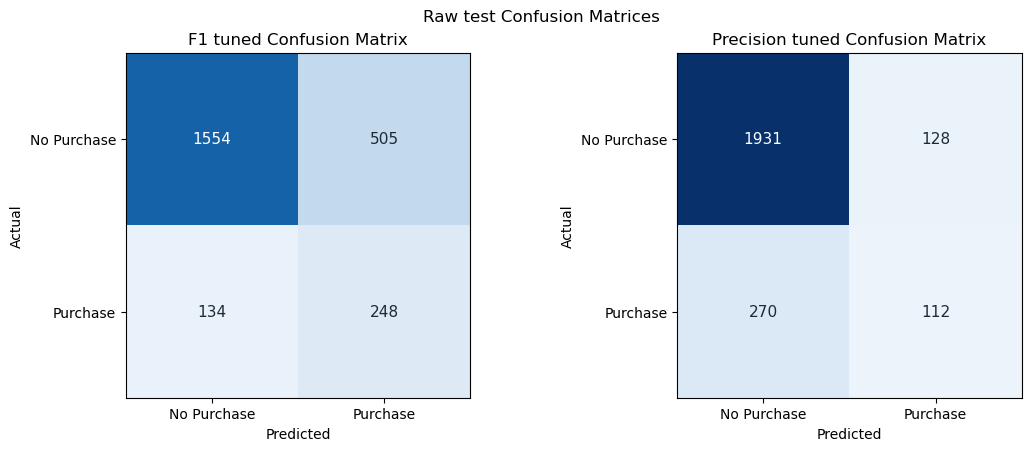

In [51]:
def make_model_outputs(f1_pred, f1_prob, precision_pred, precision_prob):
    return {
        'F1 tuned': {
            'model': best_f1_model,
            'y_pred': f1_pred,
            'y_prob': f1_prob,
        },
        'Precision tuned': {
            'model': best_precision_model,
            'y_pred': precision_pred,
            'y_prob': precision_prob,
        },
    }


model_outputs_clean = make_model_outputs(y_pred_f1, y_prob_f1, y_pred_precision, y_prob_precision)
model_outputs_raw = make_model_outputs(y_pred_f1_raw, y_prob_f1_raw, y_pred_precision_raw, y_prob_precision_raw)

# 이후 feature importance 셀과의 호환을 위해 모델 출력 기본값은 raw test 기준으로 둔다.
model_outputs = model_outputs_raw


def display_confusion_tables(label, outputs, y_eval):
    print(f'{label} confusion matrices')
    for name, output in outputs.items():
        cm = confusion_matrix(y_eval, output['y_pred'])
        confusion = pd.DataFrame(
            cm,
            index=['Actual No Purchase', 'Actual Purchase'],
            columns=['Pred No Purchase', 'Pred Purchase'],
        )
        print(f'{name} confusion matrix')
        display(confusion)


def plot_confusion_matrices(label, outputs, y_eval):
    matrices = {
        name: confusion_matrix(y_eval, output['y_pred'])
        for name, output in outputs.items()
    }
    max_count = max(cm.max() for cm in matrices.values())
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), constrained_layout=True)
    fig.suptitle(f'{label} Confusion Matrices')
    for ax, (name, cm) in zip(axes, matrices.items()):
        ax.imshow(cm, cmap='Blues', vmin=0, vmax=max_count)
        ax.set_xticks([0, 1], ['No Purchase', 'Purchase'])
        ax.set_yticks([0, 1], ['No Purchase', 'Purchase'])
        for row in range(cm.shape[0]):
            for col in range(cm.shape[1]):
                value = cm[row, col]
                text_color = 'white' if value > max_count * 0.55 else '#1f2933'
                ax.text(col, row, str(value), ha='center', va='center', color=text_color, fontsize=11)
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Actual')
        ax.set_title(f'{name} Confusion Matrix')
    plt.show()
    return matrices


display_confusion_tables('Raw test', model_outputs_raw, y_test)
confusion_matrices_raw = plot_confusion_matrices('Raw test', model_outputs_raw, y_test)
# 기존 변수명은 raw test 기준 혼동행렬을 가리키도록 유지한다.
confusion_matrices = confusion_matrices_raw


### 2.6 변수 중요도

혼동 행렬로 성능을 본 뒤, 같은 raw test 기준 모델들의 변수 중요도를 확인한다.


model,feature,importance
F1 tuned,ExitRates,0.1377
F1 tuned,total_duration,0.0943
F1 tuned,ProductRelated_Duration,0.0939
F1 tuned,BounceRates,0.0874
F1 tuned,avg_time_per_product,0.0761
F1 tuned,total_pages,0.0645
F1 tuned,ProductRelated,0.0553
F1 tuned,Administrative_Duration,0.0486
F1 tuned,Administrative,0.0446
F1 tuned,bounce_exit_ratio,0.0409


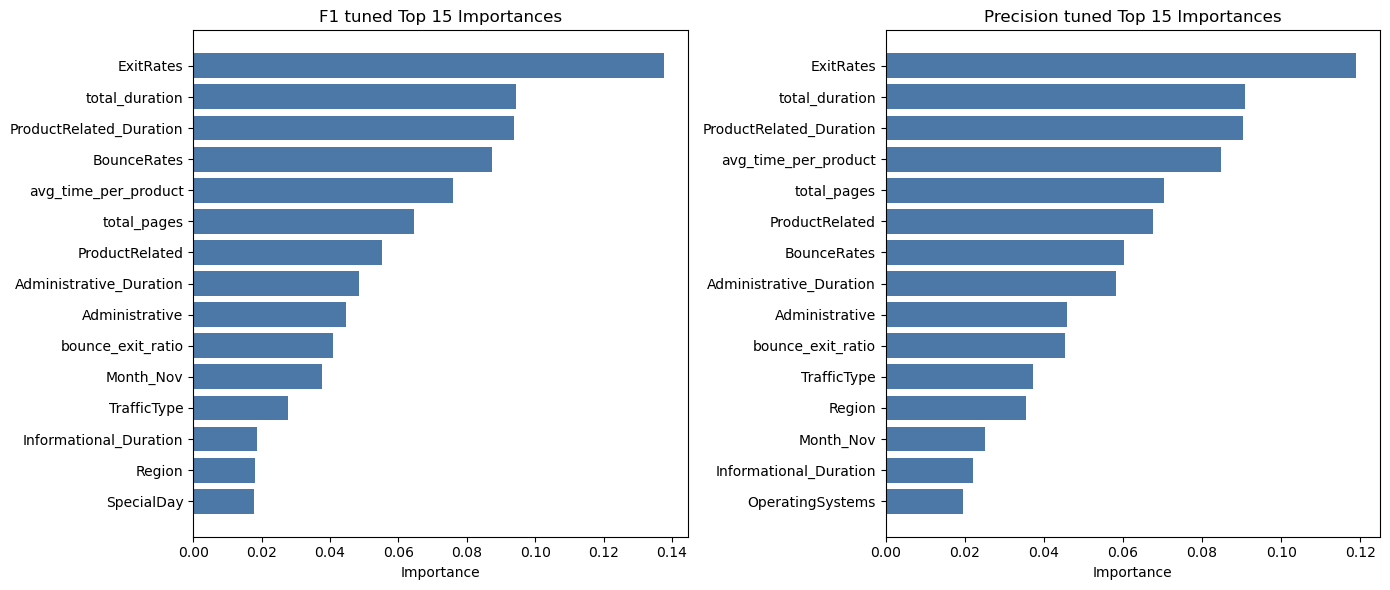

In [52]:
def feature_importance_table(name, model, columns):
    return (
        pd.DataFrame({
            'model': name,
            'feature': columns,
            'importance': model.feature_importances_,
        })
        .sort_values('importance', ascending=False)
    )


def display_importance_tables(outputs, columns):
    tables = [
        feature_importance_table(name, output['model'], columns)
        for name, output in outputs.items()
    ]
    display_side_by_side({
        table['model'].iloc[0]: table.head(15).round(4)
        for table in tables
    })
    return tables


def plot_importance_tables(importance_tables, figsize=(14, 6), color='#4c78a8'):
    fig, axes = plt.subplots(1, len(importance_tables), figsize=figsize)
    for ax, importance in zip(axes, importance_tables):
        name = importance['model'].iloc[0]
        plot_df = importance.head(15).sort_values('importance')
        ax.barh(plot_df['feature'], plot_df['importance'], color=color)
        ax.set_title(f'{name} Top 15 Importances')
        ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()


importance_tables = display_importance_tables(model_outputs, X_train.columns)
plot_importance_tables(importance_tables)

feature_importance = importance_tables[0].drop(columns=['model'])


### 변수 중요도 해석

혼동 행렬은 실제 구매자를 얼마나 놓쳤는지와 비구매를 구매로 얼마나 잘못 예측했는지를 보여준다. 변수 중요도는 Random Forest가 어떤 행동 변수에 많이 의존했는지 확인하는 해석 근거로 사용한다.


## 3. 상세 지표 및 참고 출력

ROC/PR 곡선, clean test 민감도 분석, 상세 classification report를 모아 둔다.

---


### 3.1 ROC/PR 곡선 및 상세 리포트

ROC/PR 곡선과 clean test 민감도 분석, classification report는 참고 출력으로 둔다.


,model,evaluation_set,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Random Forest default,clean test,0.8446,0.4800,0.0476,0.0866,0.7522,0.3262
1,Random Forest tuned by F1,clean test,0.7328,0.3113,0.5992,0.4098,0.7633,0.3585
2,Random Forest tuned by Precision,clean test,0.8421,0.4800,0.2381,0.3183,0.7675,0.3557


Classification report - F1 tuned model (clean test):
              precision    recall  f1-score   support

 No Purchase       0.91      0.76      0.83      1376
    Purchase       0.31      0.60      0.41       252

    accuracy                           0.73      1628
   macro avg       0.61      0.68      0.62      1628
weighted avg       0.82      0.73      0.76      1628


Classification report - F1 tuned model (raw test):
              precision    recall  f1-score   support

 No Purchase       0.92      0.75      0.83      2059
    Purchase       0.33      0.65      0.44       382

    accuracy                           0.74      2441
   macro avg       0.62      0.70      0.63      2441
weighted avg       0.83      0.74      0.77      2441

Best F1-tuned params:
{'n_estimators': 150, 'min_samples_split': 50, 'min_samples_leaf': 5, 'max_features': 'log2', 'max_depth': 12, 'criterion': 'entropy'}

Classification report - Precision tuned model (clean test):
              precision

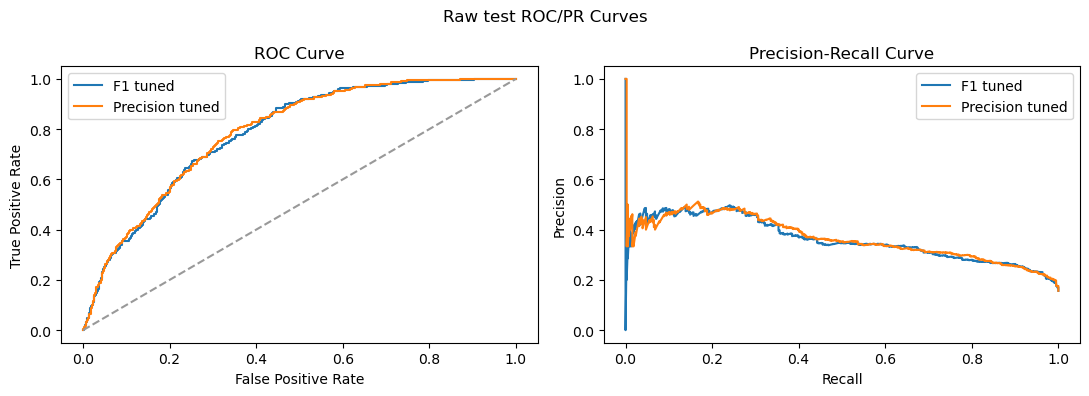

In [53]:
def plot_roc_pr_curves(label, outputs, y_eval):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    fig.suptitle(label)
    for name, output in outputs.items():
        fpr, tpr, _ = roc_curve(y_eval, output['y_prob'])
        precision, recall, _ = precision_recall_curve(y_eval, output['y_prob'])
        axes[0].plot(fpr, tpr, label=name)
        axes[1].plot(recall, precision, label=name)
    axes[0].plot([0, 1], [0, 1], linestyle='--', color='#999999')
    axes[0].set_title('ROC Curve')
    axes[0].set_xlabel('False Positive Rate')
    axes[0].set_ylabel('True Positive Rate')
    axes[0].legend()
    axes[1].set_title('Precision-Recall Curve')
    axes[1].set_xlabel('Recall')
    axes[1].set_ylabel('Precision')
    axes[1].legend()
    plt.tight_layout()
    plt.show()


display(metrics_clean.round(4))

print('Classification report - F1 tuned model (clean test):')
print(classification_report(y_test_clean, y_pred_f1, target_names=['No Purchase', 'Purchase'], zero_division=0))
print('\nClassification report - F1 tuned model (raw test):')
print(classification_report(y_test, y_pred_f1_raw, target_names=['No Purchase', 'Purchase'], zero_division=0))
print('Best F1-tuned params:')
print(f1_search.best_params_)

print('\nClassification report - Precision tuned model (clean test):')
print(classification_report(y_test_clean, y_pred_precision, target_names=['No Purchase', 'Purchase'], zero_division=0))
print('\nClassification report - Precision tuned model (raw test):')
print(classification_report(y_test, y_pred_precision_raw, target_names=['No Purchase', 'Purchase'], zero_division=0))
print('Best Precision-tuned params:')
print(precision_search.best_params_)

plot_roc_pr_curves('Raw test ROC/PR Curves', model_outputs_raw, y_test)


# ============================================================
# 4. KNN (K-최근접 이웃)
# ============================================================

# KNN Purchase Probability

전처리 노트북에서 저장한 KNN용 split 데이터로 구매 가능성 점수를 만든다.

| 실험 | 역할 |
|---|---|
| raw KNN baseline | `log1p`, `StandardScaler`, `SMOTE` 없이 원본 단위 거리만 사용 |
| Pipeline KNN | `log1p -> StandardScaler -> SMOTE -> KNN`을 CV fold 내부에서 적용 |
| 비교 기준 | raw baseline 대비 Pipeline의 순위화 성능, 탐지 폭, 확률 보정 변화 |

**처음 읽을 때 먼저 잡을 포인트**

- 여기서 KNN의 목적은 구매 여부를 예측하는 지도학습 모델을 만드는 것이다. `raw KNN baseline`은 최종 목적이 아니라 전처리 효과를 보기 위한 비교 기준이다.
- `Purchase Probability`라는 이름을 쓰지만, 이 값은 보정된 실제 구매 확률이라기보다 가까운 이웃들의 구매 라벨을 평균한 점수에 가깝다. 그래서 뒤에서 Brier와 decile 분석으로 점수 해석 한계를 따로 확인한다.
- `Pipeline KNN`은 전처리를 미리 CSV에 저장한 모델이 아니다. `log1p`, scaling, SMOTE가 교차검증 fold 안에서만 적용되도록 Pipeline에 넣은 모델이다.

## 0. KNN Pipeline 입력 데이터 로드

In [54]:
import pandas as pd

# 전처리 노트북에서 저장한 KNN용 split 데이터를 불러온다.
# 이 CSV는 SMOTE/Scaler 적용 전 데이터라서, 모델 전처리는 아래 Pipeline에서 따로 수행한다.
X_train_knn = pd.read_csv("./csv/X_train_knn.csv")
X_test_knn = pd.read_csv("./csv/X_test_knn.csv")
y_train_knn = pd.read_csv("./csv/y_train_knn.csv")["Revenue"]
y_test_knn = pd.read_csv("./csv/y_test_knn.csv")["Revenue"]

# 데이터 크기와 양성 비율을 확인해, 중복 제거 후 split 데이터가 정상 로드됐는지 점검한다.
print(f"X_train_knn: {X_train_knn.shape}")
print(f"X_test_knn : {X_test_knn.shape}")
print(f"y_train_knn: {y_train_knn.shape}, positive_ratio = {y_train_knn.mean():.4f}")
print(f"y_test_knn : {y_test_knn.shape}, positive_ratio = {y_test_knn.mean():.4f}")
print("\nColumns")
print(list(X_train_knn.columns))


X_train_knn: (9764, 11)
X_test_knn : (2441, 11)
y_train_knn: (9764,), positive_ratio = 0.1563
y_test_knn : (2441,), positive_ratio = 0.1565

Columns
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'SpecialDay', 'Weekend', 'is_new_visitor']


## 1. 기준 KNN 모델

`log1p`, `StandardScaler`, `SMOTE`를 쓰지 않은 raw KNN을 기준선으로 둔다. 중복 제거와 `PageValues` 제거는 누수 방지용 데이터 정의이므로 유지한다.

처음 보면 `KNeighborsRegressor`를 쓰는 점이 어색할 수 있다. 여기서는 `Revenue`가 0/1 라벨이므로, 가까운 이웃들의 0/1 값을 평균하면 구매 가능성 점수처럼 쓸 수 있다. 즉 분류 라벨을 바로 내는 모델이 아니라, 순위를 매길 수 있는 연속 점수를 얻기 위해 regressor 형태를 사용한다.

In [55]:
import numpy as np

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import FunctionTransformer, StandardScaler

RANDOM_STATE = 42

# KNN 거리 계산에서 큰 값이 지배하지 않도록 log1p를 적용할 우편향 수치형 컬럼을 지정한다.
KNN_LOG_COLS = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "SpecialDay",
]

# Pipeline 안에서 호출할 log1p 변환 함수다. fold마다 train 데이터에만 fit/transform 흐름이 적용되도록 함수로 묶는다.
def log1p_selected_columns(X):
    X = X.copy()
    X[KNN_LOG_COLS] = np.log1p(X[KNN_LOG_COLS])
    return X

# KNN용 모델 전처리를 한 번에 묶는다. GridSearchCV가 이 Pipeline 전체를 fold별로 새로 fit하므로 SMOTE 누수를 막을 수 있다.
def build_knn_pipeline(n_neighbors = 5, weights = "uniform", p = 2):
    return Pipeline(
        [
            ("log1p", FunctionTransformer(log1p_selected_columns, validate = False)),
            ("scaler", StandardScaler()),
            ("smote", SMOTE(random_state = RANDOM_STATE, k_neighbors = 5)),
            (
                "knn",
                KNeighborsRegressor(
                    n_neighbors = n_neighbors,
                    weights = weights,
                    p = p,
                ),
            ),
        ]
    )

BASE_K = 5

# 아무 모델 전처리도 하지 않은 raw baseline이다. 이후 Pipeline 모델과 비교해 전처리 효과를 확인한다.
raw_baseline_model = KNeighborsRegressor(n_neighbors = BASE_K, weights = "uniform", p = 2)
raw_baseline_model.fit(X_train_knn, y_train_knn)
raw_baseline_proba = raw_baseline_model.predict(X_test_knn)
raw_baseline_pred = (raw_baseline_proba >= 0.5).astype(int)

# raw baseline의 테스트 성능을 표로 정리한다. 이 값이 전처리 적용 전 기준선이다.
raw_baseline_metrics = pd.DataFrame(
    [
        {
            "model": "raw baseline",
            "Precision": precision_score(y_test_knn, raw_baseline_pred, zero_division = 0),
            "Recall": recall_score(y_test_knn, raw_baseline_pred),
            "F1": f1_score(y_test_knn, raw_baseline_pred),
            "ROC_AUC": roc_auc_score(y_test_knn, raw_baseline_proba),
            "PR_AUC": average_precision_score(y_test_knn, raw_baseline_proba),
            "Brier": brier_score_loss(y_test_knn, raw_baseline_proba),
        }
    ]
)

# raw baseline의 예측값이 어떤 범위와 분포를 갖는지 먼저 확인한다.
print("Raw baseline sample predictions")
print(raw_baseline_proba[:10])

print("\nRaw baseline prediction summary")
raw_baseline_summary = (
    pd.Series(raw_baseline_proba, name="raw_baseline_proba")
    .describe()
    .to_frame()
    .T
)
display(raw_baseline_summary)

print("Raw baseline test metrics")
display(raw_baseline_metrics.round(4))


Raw baseline sample predictions
[0.4 0.  0.2 0.  0.  0.6 0.  0.4 0.  0. ]

Raw baseline prediction summary


,count,mean,std,min,25%,50%,75%,max
raw_baseline_proba,2441.0,0.154609,0.18054,0.0,0.0,0.2,0.2,1.0


Raw baseline test metrics


,model,Precision,Recall,F1,ROC_AUC,PR_AUC,Brier
0,raw baseline,0.3016,0.0995,0.1496,0.6173,0.2084,0.1438


- raw baseline은 원본 단위 거리만 사용한 기준이 되는 모델이다.
- 결과중 ROC-AUC, PR-AUC, Recall이 낮아 구매자를 잘 끌어올리지 못하는 모델이다.

## 2. K 후보 탐색

K는 몇 명의 이웃을 평균낼지 결정하는 값이다. 작은 K는 세부 패턴에 민감하고, 큰 K는 안정적이지만 개별 패턴이 흐려지는 경향을 보인다.

```python
K_CANDIDATES = [1, 3, 5, 7, 11, 15, 21, 31, 51, 75, 101, 151]
```

| 구간 | 후보 | 보는 이유 |
|---|---|---|
| 작은 K | `1`, `3`, `5`, `7` | 가까운 몇 명만 보는 구간이다. 세부 패턴은 잘 잡지만 노이즈에도 민감하다. |
| 중간 K | `11`, `15`, `21`, `31` | 너무 예민한 상태에서 조금씩 안정화되는 구간이다. |
| 큰 K | `51`, `75`, `101`, `151` | 많은 이웃을 평균내는 구간이다. 안정적이지만 개별 패턴은 흐려질 수 있다. |

**큰 K**가 선택되면 KNN이 소수의 가까운 이웃보다 **넓은 평균**에 기대고 있다는 신호로 해석한다.  
학습 데이터가 약 9,764개라서 `sqrt(n)` 경험칙으로 보면 약 99에 가깝고, 그래서 101 같은 후보도 같이 넣었다.  
최종 선택은 경험칙이 아니라 아래 GridSearchCV의 ROC-AUC 순위로 결정한다.

## 2-1. 지표 해석

`StratifiedKFold`로 구매 비율을 유지하고, 각 fold 안에서 전처리 파이프라인을 적용하고 모델을 만들어 지표를 통해 성능을 확인한다.

| 지표 | 의미 | 해석 |
|---|---|---|
| Precision | 구매 예측 중 실제 구매 비율 | 높을수록 좋다 |
| Recall | 실제 구매자 중 잡아낸 비율 | 높을수록 좋다 |
| F1 | Precision과 Recall의 균형 | 높을수록 좋다 |
| ROC-AUC | 구매자를 비구매자보다 높은 점수로 올리는지 | 높을수록 좋다 |
| PR-AUC | 구매자가 적은 상황에서 상위 점수에 구매자가 잘 섞이는지 | 높을수록 좋다 |
| Brier | 예측 확률과 실제값의 차이 | 낮을수록 좋다 |

**지표 기준:** ROC-AUC와 PR-AUC를 중심으로 읽고, Brier와 분류 지표는 보조적으로 확인한다.

### 2-2. GridSearchCV로 K 찾기

`GridSearchCV`에는 Pipeline 전체를 넘겨 K, 거리 기준, 가중치 방식을 함께 탐색한다. 따라서 `log1p`, `StandardScaler`, `SMOTE`도 각 train fold 안에서만 적용된다.

여기서 선택 기준은 CV ROC-AUC다. 즉 0.5 임계값에서 바로 맞혔는지보다, 구매 세션을 비구매 세션보다 높은 점수로 올렸는지를 우선한다.

In [57]:
from sklearn.metrics import make_scorer
from sklearn.model_selection import GridSearchCV

# GridSearchCV의 선택 기준은 구매자 순위를 잘 올리는 ROC-AUC로 둔다.
auc_scorer = make_scorer(roc_auc_score, response_method = "predict")

# K뿐 아니라 거리 기준(p)과 이웃 가중치 방식까지 함께 탐색한다.
param_grid = {
    "knn__n_neighbors": K_CANDIDATES,
    "knn__weights": ["uniform", "distance"],
    "knn__p": [1, 2],
}

# estimator로 Pipeline 전체를 넘겨야 log1p, scaling, SMOTE가 fold 내부에서만 수행된다.
grid = GridSearchCV(
    estimator = build_knn_pipeline(),
    param_grid = param_grid,
    scoring = auc_scorer,
    cv = cv,
    n_jobs = -1,
)

grid.fit(X_train_knn, y_train_knn)

# cv_results_ 전체를 DataFrame으로 바꾼 뒤, 보고서에 필요한 컬럼만 추출한다.
grid_result_df = pd.DataFrame(grid.cv_results_)
grid_result_df = grid_result_df[[
    "param_knn__n_neighbors",
    "param_knn__weights",
    "param_knn__p",
    "mean_test_score",
    "std_test_score",
    "rank_test_score",
]].rename(columns = {
    "param_knn__n_neighbors": "K",
    "param_knn__weights": "weights",
    "param_knn__p": "p",
    "mean_test_score": "CV_ROC_AUC",
    "std_test_score": "CV_ROC_AUC_std",
    "rank_test_score": "rank",
})

# p값만 보면 직관적이지 않아 추가적으로 거리 기준 이름을 붙인다.
grid_result_df["distance"] = grid_result_df["p"].map({1: "Manhattan", 2: "Euclidean"})
grid_result_df["setting"] = grid_result_df["distance"] + " + " + grid_result_df["weights"]
# CV_ROC_AUC 값을 기준으로 내림차순 정렬한다.
grid_result_df = grid_result_df[["setting", "weights", "p", "K", "CV_ROC_AUC", "CV_ROC_AUC_std", "rank"]].sort_values("CV_ROC_AUC", ascending = False).reset_index(drop = True)

# 설정별 최고 결과만 따로 뽑아 출력한다.
grid_best_df = (
    grid_result_df
    .sort_values(["setting", "CV_ROC_AUC"], ascending = [True, False])
    .groupby("setting", as_index = False)
    .head(1)
    .sort_values("CV_ROC_AUC", ascending = False)
    .reset_index(drop = True)
)

print("Best GridSearchCV result by setting")
display(grid_best_df.round(4))

print("Top 8 GridSearchCV candidates")
display(grid_result_df.head(8).round(4))


Best GridSearchCV result by setting


,setting,weights,p,K,CV_ROC_AUC,CV_ROC_AUC_std,rank
0,Manhattan + distance,distance,1,151,0.7316,0.0166,1
1,Euclidean + distance,distance,2,151,0.7277,0.0163,4
2,Manhattan + uniform,uniform,1,101,0.7272,0.0134,5
3,Euclidean + uniform,uniform,2,101,0.7226,0.0131,13


Top 8 GridSearchCV candidates


,setting,weights,p,K,CV_ROC_AUC,CV_ROC_AUC_std,rank
0,Manhattan + distance,distance,1,151,0.7316,0.0166,1
1,Manhattan + distance,distance,1,101,0.7312,0.0128,2
2,Manhattan + distance,distance,1,75,0.7287,0.0117,3
3,Euclidean + distance,distance,2,151,0.7277,0.0163,4
4,Manhattan + uniform,uniform,1,101,0.7272,0.0134,5
5,Euclidean + distance,distance,2,101,0.7271,0.0132,6
6,Manhattan + uniform,uniform,1,151,0.7263,0.0178,7
7,Euclidean + distance,distance,2,75,0.7258,0.0119,8


- `grid_best_df`: 거리 기준과 가중치 방식별 최고 조합만 압축해서 본다.
- 큰 K 후보가 반복해서 상위권으로 나타난다. 때문에 가까운 소수 이웃보다 넓은 이웃 평균이 더 안정적이라는 걸 엿볼수 있었다.
- 결론적으로 1위는 `K=151, weights=distance, p=1`이다. 그러나 'k = 101'과 그리 큰 차이를 보이지는 않는다.

### 2-3. 결과 분석 및 K값 결정

최종 모델은 `K=151`, `weights='distance'`, `p=1` 즉 Manhattan 거리 기반 distance-weighted KNN이 선택되었다.

## 3. 최종 모델 재학습 및 테스트 평가

교차검증에서 가장 좋았던 Pipeline 조합을 전체 학습 데이터에 다시 fit하고, 테스트셋에서 최종 성능을 확인한다.

In [58]:
from sklearn.metrics import f1_score, precision_score, recall_score

# GridSearchCV 결과표에서 가장 높은 CV ROC-AUC를 보인 조합을 최종 설정으로 선택한다.
best_row = grid_result_df.iloc[0]
best_k = int(best_row["K"])
best_weights = best_row["weights"]
best_p = int(best_row["p"])
best_distance = best_row["setting"].split(" + ")[0]

# 선택된 설정으로 최종 Pipeline을 만들고 전체 학습 데이터에 다시 fit한다.
final_model = build_knn_pipeline(
    n_neighbors = best_k,
    weights = best_weights,
    p = best_p,
)
final_model.fit(X_train_knn, y_train_knn)

# 테스트셋은 모델 선택에 쓰지 않았으므로, 여기서 최종 일반화 성능을 확인한다.
test_proba = final_model.predict(X_test_knn)
test_pred = (test_proba >= 0.5).astype(int)

# 확률 순위 품질과 0.5 임계값 기준 분류 지표를 함께 정리한다.
final_metrics = pd.DataFrame(
    [
        {
            "model": "pipeline selected",
            "Precision": precision_score(y_test_knn, test_pred, zero_division=0),
            "Recall": recall_score(y_test_knn, test_pred),
            "F1": f1_score(y_test_knn, test_pred),
            "ROC_AUC": roc_auc_score(y_test_knn, test_proba),
            "PR_AUC": average_precision_score(y_test_knn, test_proba),
            "Brier": brier_score_loss(y_test_knn, test_proba),
        }
    ]
)

print("Final Pipeline model")
print(
    f"K = {best_k}, weights = {best_weights}, "
    f"p = {best_p} ({best_distance})"
)
print(
    f"test predicted probability range: "
    f"{test_proba.min():.4f} ~ {test_proba.max():.4f}"
)
print(f"test mean predicted probability: {test_proba.mean():.4f}")
print(f"test actual purchase ratio: {y_test_knn.mean():.4f}")

display(final_metrics.round(4))


Final Pipeline model
K = 151, weights = distance, p = 1 (Manhattan)
test predicted probability range: 0.0000 ~ 1.0000
test mean predicted probability: 0.4578
test actual purchase ratio: 0.1565


,model,Precision,Recall,F1,ROC_AUC,PR_AUC,Brier
0,pipeline selected,0.2427,0.8246,0.375,0.7284,0.2988,0.2352


- ROC-AUC, PR-AUC: 구매 가능성이 높은 세션을 위쪽으로 올리는 능력을 지표화 하였습니다.
- Recall이 높고 Precision이 낮아 오탐색이 많음을 보여주고 있다. 여기서 이 모델을 `1차 후보 선별`로 해석하게 된다.
- Brier는 낮을수록 좋은 값이다. 여기서는 기존 모델보다는 높게 나와 실제 구매 확률로 읽기는 어려워졌다.
- 테스트 평균 예측값이 실제 구매율보다 훨씬 높게 나와 숫자 자체보다 순위와 구간별 실제 구매율을 중심으로 읽어야 한다.

## 4. 기준 모델 대비 개선 분석

`test_compare`는 무전처리 raw baseline과 최종 Pipeline의 실제 테스트 성능 차이를 보여준다.

In [83]:
# 테스트셋에서는 무전처리 raw baseline과 최종 Pipeline을 나란히 비교해 전처리 효과를 확인한다.
test_compare = pd.concat(
    [
        raw_baseline_metrics.assign(preprocessing = "none"),
        final_metrics.assign(preprocessing = "log1p + scaler + SMOTE"),
    ],
    ignore_index = True,
)

# raw baseline 대비 최종 Pipeline의 테스트 지표 변화량과 퍼센트 변화를 계산한다.
metric_cols = ["ROC_AUC", "PR_AUC", "Brier", "Precision", "Recall", "F1"]

print("Test comparison: raw baseline vs selected Pipeline")
display(test_compare.round(4))


Test comparison: raw baseline vs selected Pipeline


,model,Precision,Recall,F1,ROC_AUC,PR_AUC,Brier,preprocessing
0,raw baseline,0.3016,0.0995,0.1496,0.6173,0.2084,0.1438,none
1,pipeline selected,0.2427,0.8246,0.3750,0.7284,0.2988,0.2352,log1p + scaler + SMOTE


- 테스트 ROC-AUC: raw baseline 대비 약 `+18.0%` 개선되어 순위화 성능이 좋아졌으며
- 테스트 PR-AUC: 약 `+43.3%` 개선되어 불균형 데이터에서 구매자 상위 포착력이 좋아졌다.
- Recall과 F1은 크게 올랐지만 Precision은 낮아졌다. 구매자를 더 많이 잡는 대신 오탐이 늘어난 구조다.
- Brier는 약 `+63.5%` 나빠졌다. 예측값을 보정된 실제 구매 확률로 해석하면 안 된다.

**따라서 순위화, PR-AUC, Recall은 좋아졌지만 확률 보정과 Precision은 약해졌다.**

## 5. KNN 결과로 확인할 수 있는 인사이트

여기서는 성능 지표보다 모델 점수의 의미를 해석하여 예측 점수가 실제 구매율을 얼마나 잘 정렬하는지, 어떤 행동 패턴을 구매 신호로 보는지, 그리고 KNN 확률값을 어디까지 믿을 수 있는지 확인합니다.

### 5-1. 예측 확률 구간별 실제 구매율

예측 확률을 10개 구간으로 나누어, 상위 구간일수록 실제 구매율이 높아지는지 확인한다.

In [60]:
# 테스트셋의 예측 확률과 실제 구매 여부를 하나의 표로 정리
test_result = pd.DataFrame({
    "predicted_proba": test_proba,
    "actual_revenue": y_test_knn,
})

# score_decile: 예측 확률 순위 기준 10개 구간, 10이 가장 높은 구간
test_result["score_decile"] = pd.qcut(
    test_result["predicted_proba"].rank(method = "first"),
    q = 10,
    labels = range(1, 11),
).astype(int)

# 예측 점수 구간별 실제 구매율과 구매자 수 집계
decile_result = (
    test_result
    .groupby("score_decile")
    .agg(
        count = ("actual_revenue", "size"),
        mean_predicted_proba = ("predicted_proba", "mean"),
        actual_purchase_rate = ("actual_revenue", "mean"),
        actual_buyers = ("actual_revenue", "sum"),
    )
    .reset_index()
)

# 상위 구간으로 갈수록 실제 구매율이 높아지는지 확인
display(decile_result.round(4))

,score_decile,count,mean_predicted_proba,actual_purchase_rate,actual_buyers
0,1,245,0.0093,0.0122,3
1,2,244,0.0917,0.0205,5
2,3,244,0.2475,0.0451,11
3,4,244,0.3982,0.0820,20
4,5,244,0.4880,0.1803,44
5,6,244,0.5574,0.1434,35
6,7,244,0.6161,0.2377,58
7,8,244,0.6661,0.2623,64
8,9,244,0.7160,0.2705,66
9,10,244,0.7892,0.3115,76


- 이 표는 예측 확률을 10개 구간으로 나눈 뒤, 각 구간의 실제 구매율을 확인한 것이다. 즉, 모델 점수가 높은 그룹이 실제로도 더 많이 구매했는지 보는 순위 검증이다.
- 현재 결과는 1구간 실제 구매율이 약 `1.2%`, 10구간이 약 `31.1%`다. 최상위 구간의 구매율이 최하위 구간보다 약 25배 높았다.
- 다만 모든 구간이 완벽하게 단조 증가하지는 않았다. 예를 들어 5구간(0.1803)보다 6구간(0.1434) 구매율이 낮았다. 
**따라서 점수의 큰 방향성은 믿을 수 있지만, `0.56이면 실제 구매확률 56%`처럼 개별 확률값을 그대로 해석하지는 못한다**

### 5-2. 예측 상위 그룹과 하위 그룹의 행동 차이

예측 확률 상위 10%와 하위 10%의 원래 단위 행동 지표 평균을 비교한다.

In [61]:
# 상위 10%, 하위 10%를 추출하기 위한 boolean mask 생성
top_group = test_result["score_decile"] == 10
bottom_group = test_result["score_decile"] == 1

# 상위/하위 그룹의 원래 단위 입력 변수 평균 계산
top_profile = X_test_knn.loc[top_group].mean()
bottom_profile = X_test_knn.loc[bottom_group].mean()

# 두 그룹의 평균 차이를 하나의 표로 정리
profile_compare = pd.DataFrame({
    "top_10pct_mean": top_profile,
    "bottom_10pct_mean": bottom_profile,
})
profile_compare["difference"] = profile_compare["top_10pct_mean"] - profile_compare["bottom_10pct_mean"]
profile_compare["abs_difference"] = profile_compare["difference"].abs()

# 차이가 큰 변수부터 확인할 수 있도록 정렬
profile_compare = profile_compare.sort_values("abs_difference", ascending = False)

# 예측 상위 그룹과 하위 그룹의 행동 차이 출력
display(profile_compare)

,top_10pct_mean,bottom_10pct_mean,difference,abs_difference
ProductRelated_Duration,2827.780186,66.734091,2761.046095,2761.046095
Administrative_Duration,162.654130,0.081633,162.572498,162.572498
Informational_Duration,84.122119,0.093878,84.028242,84.028242
ProductRelated,71.758197,3.975510,67.782687,67.782687
Administrative,4.135246,0.008163,4.127083,4.127083
Informational,1.139344,0.020408,1.118936,1.118936
is_new_visitor,0.356557,0.016327,0.340231,0.340231
SpecialDay,0.011475,0.164082,-0.152606,0.152606
ExitRates,0.014575,0.146582,-0.132007,0.132007
Weekend,0.258197,0.142857,0.115340,0.115340


- 이 표는 예측 상위 10%와 하위 10%가 실제 행동 지표에서 얼마나 다른지 보여줍니다. KNN이 높은 점수를 준 세션이 어떤 모습인지 설명하는 용도입니다.
- 상위 그룹은 `ProductRelated_Duration`이 약 `2827.8`, 하위 그룹은 약 `66.7`이다. 상품 관련 페이지에 머문 시간이 압도적으로 길기 때문에, 모델은 상품 탐색 강도를 강한 구매 신호로 보게 됩니다.
- `ProductRelated`도 상위 그룹이 약 `71.8`, 하위 그룹이 약 `4.0`으로 차이가 크다. 단순 방문보다 여러 상품 페이지를 오래 탐색한 세션이 높은 점수를 받는다.
- 반대로 `ExitRates`, `BounceRates`는 상위 그룹에서 낮다. 높은 점수를 받은 사용자는 바로 이탈하기보다 사이트 안에서 더 오래 움직인 사용자에 가깝다고 본다.
- `is_new_visitor` 차이도 크다. 이 결과만 보면 신규 방문자 여부가 모델 점수에 영향을 주지만 신규 방문자가 무조건 구매 확률이 높다는 인과관계를 뜻하지는 않는다.

### 5-3. Permutation Importance

컬럼을 하나씩 섞었을 때 ROC-AUC가 얼마나 떨어지는지 확인해, KNN이 의존한 예측 신호를 본다.

In [62]:
from sklearn.inspection import permutation_importance

# permutation importance도 ROC-AUC 감소량 기준으로 계산
permutation_scorer = make_scorer(roc_auc_score, response_method = "predict")

# 각 컬럼을 반복적으로 섞어 모델 성능 감소량 측정
importance = permutation_importance(
    final_model,
    X_test_knn,
    y_test_knn,
    scoring = permutation_scorer,
    n_repeats = 5,
    random_state = 42,
)

# 컬럼별 중요도 평균과 표준편차를 표로 정리
importance_result = pd.DataFrame({
    "feature": X_test_knn.columns,
    "importance_mean": importance.importances_mean,
    "importance_std": importance.importances_std,
})

# 성능 감소가 큰 변수부터 확인할 수 있도록 정렬
importance_result = importance_result.sort_values("importance_mean", ascending = False)

# KNN 모델이 많이 의존한 예측 신호 출력
display(importance_result)

,feature,importance_mean,importance_std
10,is_new_visitor,0.031544,0.006249
5,ProductRelated_Duration,0.021094,0.008069
7,ExitRates,0.019201,0.004082
4,ProductRelated,0.013856,0.003195
6,BounceRates,0.004052,0.004344
1,Administrative_Duration,0.003312,0.003525
8,SpecialDay,0.002750,0.004105
0,Administrative,0.000434,0.003368
3,Informational_Duration,-0.008246,0.002192
9,Weekend,-0.008749,0.003096


- Permutation Importance는 특정 컬럼을 섞어서 그 정보만 망가뜨렸을 때 ROC-AUC가 얼마나 떨어지는지 보는 방식이다. 많이 떨어질수록 모델이 그 컬럼에 더 의존했다는 뜻이다.
- 현재는 `is_new_visitor`, `ProductRelated_Duration`, `ExitRates`, `ProductRelated`가 위에 있다. 즉, 최종 KNN은 방문자 유형, 상품 탐색 시간, 이탈률, 상품 페이지 수를 핵심 거리 신호로 사용한다고 본다.
- 이 결과는 5-2의 상·하위 그룹 비교와도 연결된다. 높은 점수를 받은 그룹이 상품 페이지를 많이 보고 오래 머물렀고, permutation에서도 같은 계열 변수가 중요하게 나온다.
- `Informational`, `Weekend`처럼 음수로 나온 변수는 이 테스트셋에서는 섞어도 성능이 떨어지지 않았거나 오히려 약간 나아졌다는 뜻이다. 이런 변수는 KNN 거리 계산에서 도움이 불안정하거나 잡음처럼 작동했을 가능성이 있다.

### 5-4. KNN 이웃 예시 확인

예측 확률이 가장 높은 방문자 1명을 골라, 최종 KNN 공간에서 가까운 이웃 일부를 확인한다.

In [63]:
# 예측 확률이 가장 높은 테스트 방문자 1명을 선택한다.
target_idx = int(test_result.sort_values("predicted_proba", ascending = False).index[0])

# Pipeline 앞단 변환을 직접 통과시켜, 최종 KNN 단계가 보는 좌표계로 변환한다.
target_after_log = final_model.named_steps["log1p"].transform(
    X_test_knn.iloc[[target_idx]]
)
target_scaled = final_model.named_steps["scaler"].transform(target_after_log)

# SMOTE 이후 학습 공간에서 가장 가까운 이웃을 찾는다.
knn_step = final_model.named_steps["knn"]
distances, neighbor_idx = knn_step.kneighbors(target_scaled, n_neighbors = best_k)

neighbor_result = pd.DataFrame(
    {
        "neighbor_rank": range(1, best_k + 1),
        "distance": distances[0],
        "neighbor_revenue": knn_step._y[neighbor_idx[0]],
    }
)

# 이웃 표 전체를 다 보기보다, 예측을 해석하는 핵심 요약 지표를 먼저 만든다.
neighbor_summary = pd.DataFrame(
    [
        {
            "target_test_index": target_idx,
            "predicted_proba": test_result.loc[target_idx, "predicted_proba"],
            "actual_revenue": test_result.loc[target_idx, "actual_revenue"],
            "K": best_k,
            "buyers_among_K": neighbor_result["neighbor_revenue"].sum(),
            "buyer_ratio_among_K": neighbor_result["neighbor_revenue"].mean(),
            "nearest_distance": neighbor_result["distance"].min(),
            "median_distance": neighbor_result["distance"].median(),
            "max_distance": neighbor_result["distance"].max(),
        }
    ]
)

print(f"target test index: {target_idx}")
print(
    f"predicted purchase probability: "
    f"{test_result.loc[target_idx, 'predicted_proba']:.4f}"
)
print(f"actual revenue: {test_result.loc[target_idx, 'actual_revenue']}")
print(
    f"buyers among nearest {best_k} neighbors: "
    f"{neighbor_result['neighbor_revenue'].sum()}"
)

display(neighbor_summary.round(4))

# K가 클 수 있으므로 가까운 이웃 표는 상위 20개만 출력한다.
display(neighbor_result.head(20))


target test index: 806
predicted purchase probability: 1.0000
actual revenue: 0
buyers among nearest 151 neighbors: 6


,target_test_index,predicted_proba,actual_revenue,K,buyers_among_K,buyer_ratio_among_K,nearest_distance,median_distance,max_distance
0,806,1.0,0,151,6,0.0397,0.0,0.8022,0.8022


,neighbor_rank,distance,neighbor_revenue
0,1,0.000000,1
1,2,0.027485,1
2,3,0.623814,0
3,4,0.623814,0
4,5,0.686241,1
5,6,0.688914,1
6,7,0.711528,1
7,8,0.802226,0
8,9,0.802226,0
9,10,0.802226,0


**읽는 법**

- 이 예시는 예측 확률이 가장 높은 테스트 샘플을 일부러 고른 것이다. 특이점은 예측 확률이 `1.0`인데 실제 구매 여부는 `0`이라는 점이다.
- 더 특이한 점은 `K=151`인데 구매 이웃은 6명뿐이라는 것이다. 보통 단순 평균만 생각하면 구매 이웃이 적으니 낮은 점수가 나와야 할 것처럼 보인다.
- 하지만 최종 모델은 `distance` 가중치를 쓴다. 가장 가까운 이웃의 거리가 `0`이고 그 이웃이 구매자이면, 멀리 있는 다수의 비구매 이웃보다 이 가까운 구매 이웃이 예측을 강하게 끌어올릴 수 있다.
- 또한 이 이웃 탐색은 SMOTE 이후의 학습 공간에서 일어난다. 그래서 이 결과를 `실제 과거 방문자 151명 중 6명만 구매했다`로 읽으면 안 되고, 최종 모델이 보는 거리 공간에서의 예시로 읽어야 한다.
- 그래서 이 사례는 KNN 확률값의 한계를 잘 보여준다. 모델 점수는 실제 구매 확률이라기보다, 현재 샘플이 구매자와 얼마나 가까운 패턴을 가졌는지 나타내는 거리 기반 우선순위 점수로 해석하는 편이 안전하다.

### 5-5. 최종 해석

**핵심 결론**

최종 KNN Pipeline은 실제 구매 확률을 정밀하게 맞히는 모델이라기보다, 구매 가능성이 높은 세션을 먼저 걸러내는 1차 우선순위 모델로 보는 것이 적절하다.

**근거**

- 예측 점수 상위 decile의 실제 구매율이 최하위 decile보다 훨씬 높다. 즉, 점수가 높을수록 실제 구매 가능성이 높아지는 방향성은 있다.
- 예측 상위 그룹은 상품 페이지를 많이 보고 오래 머물며, `ExitRates`와 `BounceRates`가 낮다. 모델은 사이트 안에서 적극적으로 상품을 탐색한 행동을 구매 신호로 본다.
- permutation 결과에서도 `is_new_visitor`, `ProductRelated_Duration`, `ExitRates`, `ProductRelated`가 중요하게 나왔다. 이는 5-2의 상·하위 그룹 비교와 같은 방향이다.

**주의점**

- 예측 확률 `1.0`이 실제 구매를 보장하지 않는다.
- `distance` 가중치에서는 아주 가까운 구매 이웃 하나가 전체 점수를 크게 끌어올릴 수 있다.
- Brier가 나빠졌기 때문에, 예측값을 보정된 실제 구매 확률로 해석하면 위험하다.

**따라서**

이 모델은 “누가 반드시 구매하는가”를 답하는 모델이 아니라, 마케팅이나 분석 상황에서 “어떤 세션을 먼저 확인할 것인가”를 정하는 데 더 적합하다.

# ============================================================
# 5. K-Means (군집화)
# ============================================================

# 온라인 쇼핑 세션 군집화 (K-Means) - 행동 기반 방문자 세분화

지도학습 3종(Decision Tree / Random Forest / KNN)이 **"이 세션이 구매할까?"** 를 예측했다면,
이 노트북은 비지도 학습으로 **"방문자가 행동상 어떤 유형으로 나뉘는가, 유형별 구매율은 어떻게 다른가"** 를 분석한다.

핵심 원칙:
1. **`Revenue`(구매 여부)는 군집 학습에 사용하지 않는다.** 순수하게 행동 변수만으로 군집을 만든 뒤,
   사후에 군집별 실제 구매율을 붙여 해석/검증한다. (비지도의 정의를 지킴)
2. **KNN 전처리 입력을 그대로 재사용한다.** K-Means도 유클리드 거리 기반이라 KNN과 요구사항이 같다
   (ID 변수·Month 제외, 11개 수치 컬럼, `PageValues` 누수 변수 제외).
3. 군집은 기술적(descriptive) 분석이므로 train/test를 합친 전체 세션(중복 제거 후 12,205건)에 적용한다.

**처음 읽을 때 먼저 잡을 포인트**

- K-Means는 구매 여부를 맞히는 모델이 아니다. 행동이 비슷한 세션끼리 묶은 뒤, 그 묶음이 구매율과 어떤 관계가 있는지 사후에 확인하는 분석이다.
- `Revenue`는 학습 입력에서 제외한다. 이후 표에 나오는 구매율은 군집을 설명하고 검증하기 위한 외부 참고값이지, 군집을 만들 때 사용한 정답 라벨이 아니다.
- 군집 번호 `0/1/2` 자체에는 의미가 없다. 의미는 군집별 행동 평균을 보고 사람이 붙인 `Bouncers`, `Browsers`, `Engaged` 라벨에서 생긴다.

In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# 군집용 전처리(표준화), K-Means 군집, 2D 시각화(PCA)에 쓰는 핵심 도구
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
# 7.5 일반화 검증에서 train/test로 나눌 때 사용
from sklearn.model_selection import train_test_split
# 군집 성능 평가용 지표 모음
#  - 내부지표(정답 불필요): silhouette, davies_bouldin, calinski_harabasz
#  - 외부지표(Revenue와 비교): adjusted_rand_score, normalized_mutual_info_score, homogeneity_completeness_v_measure
from sklearn.metrics import (
    silhouette_score, silhouette_samples,
    davies_bouldin_score, calinski_harabasz_score,
    adjusted_rand_score, normalized_mutual_info_score,
    homogeneity_completeness_v_measure)
# chi2_contingency: 군집별 구매율 차이가 우연인지 검정 / linear_sum_assignment: 수렴 시각화에서 프레임 색 통일
from scipy.stats import chi2_contingency
from scipy.optimize import linear_sum_assignment
import itertools

# 전역 설정
# 재현되도록 시드 고정
RANDOM_STATE = 42

# 출력·그래프 기본 설정
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 200)
plt.rcParams['figure.figsize'] = (8, 4.5)

## 1. 데이터 로드

KNN 전처리 산출물(`models/knn/csv/`)을 재사용한다. 이 CSV는 `log1p`/스케일/SMOTE 적용 **전** 데이터라
군집용 전처리(log1p → 표준화)를 이 노트북에서 직접 수행한다. train/test를 모두 합쳐 전체 세션을 군집한다.

여기서 KNN 입력을 재사용한다는 말은 `같은 11개 행동 변수와 PageValues 제거 기준을 쓴다`는 뜻이다. KNN의 SMOTE까지 재사용하는 것은 아니다. K-Means는 비지도 군집화라서 구매자 수를 인위적으로 늘리는 SMOTE를 적용하지 않는다.


In [65]:
# 데이터 로드
X_train = pd.read_csv('./csv/X_train_knn.csv', encoding = 'utf-8')
X_test = pd.read_csv('./csv/X_test_knn.csv', encoding = 'utf-8')
y_train = pd.read_csv('./csv/y_train_knn.csv', encoding = 'utf-8')['Revenue']
y_test = pd.read_csv('./csv/y_test_knn.csv', encoding = 'utf-8')['Revenue']

# 예측이 아니라 전체 구조를 보려는 거라 train/test를 합친다
X = pd.concat([X_train, X_test], ignore_index = True)
# y(구매여부)는 군집 학습에 안 쓰고 나중에 군집별 구매율 볼 때만 참고
y = pd.concat([y_train, y_test], ignore_index = True)

print(f'전체 세션   : {X.shape},  실제 구매율(참고용): {y.mean():.4f}')
print(f'사용 변수({X.shape[1]}개): {list(X.columns)}')
X.head()

전체 세션   : (12205, 11),  실제 구매율(참고용): 0.1563
사용 변수(11개): ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'SpecialDay', 'Weekend', 'is_new_visitor']


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,SpecialDay,Weekend,is_new_visitor
0,8,203.6,1,0.0,42,1052.400000,0.0,0.004545,0.0,0,0
1,0,0.0,0,0.0,30,901.288889,0.0,0.007333,0.0,0,1
2,0,0.0,0,0.0,13,421.166667,0.0,0.028205,0.8,0,0
3,2,40.0,0,0.0,5,558.500000,0.0,0.028571,0.0,1,1
4,0,0.0,0,0.0,16,1599.266667,0.0,0.013333,0.0,0,0


## 2. 군집용 전처리 (log1p → 표준화)

K-Means는 거리 기반이라 스케일에 민감하다. 두 단계를 거친다.

1. **`log1p`** — 페이지 수/체류 시간/이탈률 등 강한 우편향 변수의 큰 값이 거리를 지배하지 않도록 압축.
2. **`StandardScaler`** — 모든 변수를 평균 0/표준편차 1로 맞춰 동등한 비중으로 거리 계산.

`Revenue`는 여기에 포함되지 않는다(비지도 유지). `Weekend`, `is_new_visitor`는 이미 0/1이라 log는 생략한다.


In [66]:
# 전처리 1: 한쪽으로 치우친 변수 펴기 (log 변환)
# 페이지 수·체류시간은 대부분 작고 일부만 아주 큰 분포라
# 큰 값이 거리를 지배하지 않게 log로 눌러준다
LOG_COLS = [
    'Administrative', 'Administrative_Duration',
    'Informational', 'Informational_Duration',
    'ProductRelated', 'ProductRelated_Duration',
    'BounceRates', 'ExitRates', 'SpecialDay',
]
# Weekend·is_new_visitor는 0/1이라 로그 제외
X_log = X.copy()
X_log[LOG_COLS] = np.log1p(X_log[LOG_COLS])

# 전처리 2: 변수 단위 맞추기 (표준화)
# 표준화해서 변수마다 거리 비중을 맞춘다
scaler = StandardScaler()
Z = scaler.fit_transform(X_log)   # Z: 표준화된 11차원 데이터(군집의 실제 입력)

print(f'스케일링 완료: {Z.shape}')
print('변환 후 각 컬럼 평균(≈0)/표준편차(≈1) 확인:')
scaled_summary = (
    pd.DataFrame(Z, columns = X.columns)
    .describe()
    .loc[['mean', 'std']]
    .round(3)
)
print(scaled_summary)

스케일링 완료: (12205, 11)
변환 후 각 컬럼 평균(≈0)/표준편차(≈1) 확인:
      Administrative  Administrative_Duration  Informational  Informational_Duration  ProductRelated  ProductRelated_Duration  BounceRates  ExitRates  SpecialDay  Weekend  is_new_visitor
mean            -0.0                      0.0            0.0                     0.0            -0.0                     -0.0          0.0        0.0         0.0     -0.0             0.0
std              1.0                      1.0            1.0                     1.0             1.0                      1.0          1.0        1.0         1.0      1.0             1.0


## 3. 군집 개수 K 선택 — 엘보우 + 실루엣

K는 "정답"이 없으므로 두 지표를 함께 본다.

- **엘보우(inertia)**: 군집 내 거리 제곱합. 꺾이는 지점(추가 군집의 이득이 줄어드는 곳)을 찾는다.
- **실루엣 계수**: 군집이 얼마나 뚜렷하게 분리됐는지(−1~1, 높을수록 좋음).

자동 argmax로 기계적으로 고르지 않고, 두 지표 + **해석 가능성**을 함께 근거로 K를 정한다.

주의할 점은 실루엣 점수가 가장 높은 K를 무조건 고르는 문제가 아니라는 것이다. 군집 분석은 이후 사람이 라벨을 붙이고 전략으로 해석해야 하므로, 지표가 비슷하면 너무 잘게 쪼개진 K보다 설명 가능한 K를 선택한다.


 K     inertia  silhouette
 2 102581.6096      0.2328
 3  80645.5998      0.3225
 4  65272.1159      0.2753
 5  56185.6057      0.2993
 6  48222.5088      0.3218
 7  43893.8020      0.3274
 8  40877.3224      0.2944
 9  38527.4336      0.2914
10  36418.7173      0.3118


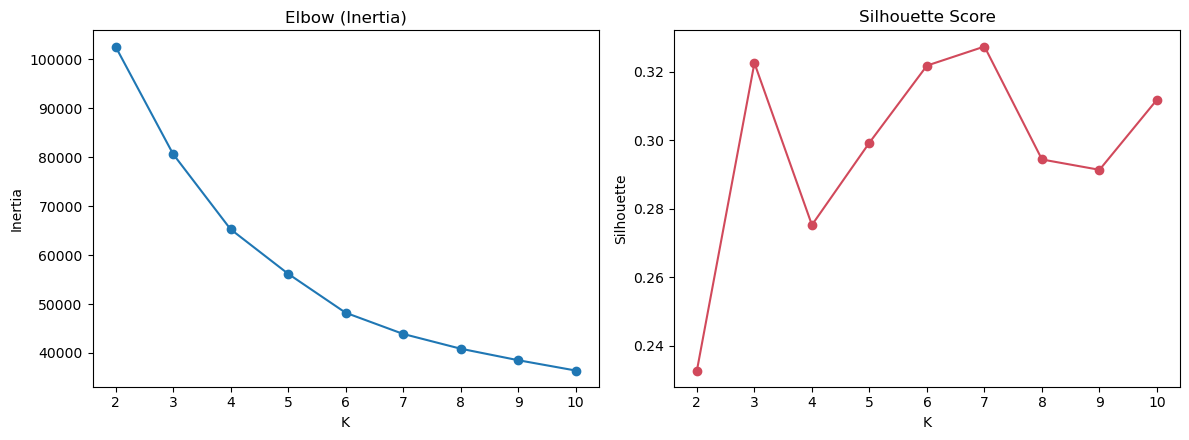

In [67]:
# 적정 군집 수(K) 탐색: 엘보우 + 실루엣
# K는 정답이 없어서 여러 개 돌려보고 두 지표로 고른다
K_CANDIDATES = list(range(2, 11))   # 시험할 K 후보(군집 2개 ~ 10개)
SILHOUETTE_SAMPLE = 4000            # 실루엣은 표본이 크면 느려서 4,000개만 뽑아 근사(속도용)

sweep = []
for k in K_CANDIDATES:
    # n_init=10: 초기값 10번 시도해 best 선택
    km = KMeans(
        n_clusters = k,
        random_state = RANDOM_STATE,
        n_init = 10,
    )
    labels = km.fit_predict(Z)
    sil = silhouette_score(Z, labels, sample_size = SILHOUETTE_SAMPLE, random_state = RANDOM_STATE)
    sweep.append({'K': k, 'inertia': km.inertia_, 'silhouette': sil})

sweep_df = pd.DataFrame(sweep)
print(sweep_df.round(4).to_string(index = False))

# 엘보우 꺾이는 점과 실루엣 정점을 같이 본다
fig, axes = plt.subplots(1, 2, figsize = (12, 4.5))
axes[0].plot(
    sweep_df['K'],
    sweep_df['inertia'],
    marker = 'o',
)
axes[0].set_title('Elbow (Inertia)')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertia')

axes[1].plot(
    sweep_df['K'],
    sweep_df['silhouette'],
    marker = 'o',
    color = '#d1495b',
)
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Silhouette')
plt.tight_layout()
plt.show()

### K 선택 근거

엘보우(inertia)는 K=2→3에서 가장 크게 꺾인 뒤 완만해진다. 실루엣은 K=3과 7에서 높게(≈0.32) 나오는데, 7개로 나누면 해석이 너무 복잡해진다. 그래서 K=3으로 정했다.

In [68]:
# 최종 군집 학습 (K=3)
# K=3이면 즉시이탈/일반탐색/고관여로 깔끔하게 나뉜다
BEST_K = 3

kmeans = KMeans(
    n_clusters = BEST_K,
    random_state = RANDOM_STATE,
    n_init = 10,
)
cluster_labels = kmeans.fit_predict(Z)   # 각 세션이 어느 군집(0/1/2)에 속하는지

# 해석용으로 원본 변수+군집번호+구매여부를 한 표에 모은다
profile = X.copy()
profile['cluster'] = cluster_labels
profile['Revenue'] = y.values # 학습엔 안 쓰고 사후 해석에만 사용

print(f'최종 군집 (K={BEST_K})')
print(profile['cluster'].value_counts().sort_index())

최종 군집 (K=3)
cluster
0    8988
1    2313
2     904
Name: count, dtype: int64


## 4. 군집 프로파일 — 각 유형은 어떤 방문자인가

원래 단위(역변환 불필요, 평균은 원본 스케일로 해석)로 군집별 평균을 본다.
어떤 행동 변수가 군집을 가르는지 확인한다.


In [69]:
# 군집별 프로파일: 어떤 행동의 군집인가
# 군집별 평균으로 어떤 방문자인지 본다
profile_table = profile.groupby('cluster').agg(
    size = ('Revenue', 'size'),                                     # 군집 크기(세션 수)
    purchase_rate = ('Revenue', 'mean'),                            # 군집별 실제 구매율(0~1)
    ProductRelated = ('ProductRelated', 'mean'),                    # 상품 페이지 조회 수
    ProductRelated_Duration = ('ProductRelated_Duration', 'mean'),  # 상품 페이지 체류시간
    Administrative = ('Administrative', 'mean'),                    # 관리(계정 등) 페이지 수
    BounceRates = ('BounceRates', 'mean'),                          # 첫 페이지에서 바로 이탈한 비율
    ExitRates = ('ExitRates', 'mean'),                              # 페이지를 떠난 비율
    is_new_visitor = ('is_new_visitor', 'mean'),                    # 신규 방문자 비율
    Weekend = ('Weekend', 'mean'),                                  # 주말 세션 비율
)
profile_table['size_pct'] = profile_table['size'] / profile_table['size'].sum()  # 전체 대비 비중
print(profile_table.round(3).to_string())

         size  purchase_rate  ProductRelated  ProductRelated_Duration  Administrative  BounceRates  ExitRates  is_new_visitor  Weekend  size_pct
cluster                                                                                                                                         
0        8988          0.150          26.305                  964.478           1.856        0.009      0.033           0.159    0.229     0.736
1        2313          0.240          65.822                 2604.715           5.113        0.007      0.022           0.102    0.275     0.190
2         904          0.004           2.705                   41.798           0.043        0.163      0.179           0.033    0.183     0.074


### 군집 해석 (네이밍)

| cluster | 규모 | 구매율 | 행동 특징 | 라벨 |
|---|---:|---:|---|---|
| 즉시 이탈형 | ~7% | **~0.4%** | 상품 페이지 ~3개·체류 ~40초, BounceRate/ExitRate 매우 높음 | **Bouncers** |
| 일반 탐색형 | ~74% | ~15% | 평균적 탐색(상품 ~26페이지), 전체의 다수 | **Browsers** |
| 고관여형 | ~19% | **~24%** | 상품 ~66페이지·체류 ~2,600초, Administrative 페이지도 많음 | **Engaged buyers** |

핵심 인사이트: **세션 깊이(ProductRelated 페이지 수·체류 시간)가 깊어질수록 구매율이 단조 상승**한다
(0.4% → 15% → 24%). 이탈률(Bounce/Exit)이 높은 군집은 거의 구매하지 않는다.

여기서 라벨은 모델이 자동으로 붙인 이름이 아니라 사람이 해석을 위해 붙인 이름이다. 특히 `Engaged buyers`는 `모두 구매자`라는 뜻이 아니라, 구매율이 상대적으로 높은 고관여 세션이라는 뜻으로 읽어야 한다.


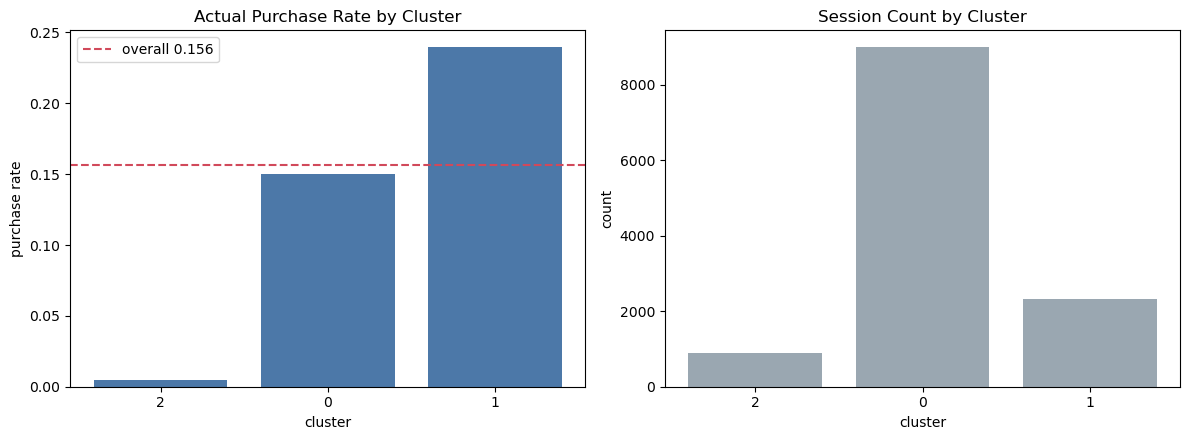

In [70]:
# 군집별 구매율·규모 시각화
# 구매율 순으로 정렬해 유형별로 구매율이 오르는지 본다
order = profile_table.sort_values('purchase_rate').index

fig, axes = plt.subplots(1, 2, figsize = (12, 4.5))

# (좌) 군집별 구매율 — 점선은 전체 평균 구매율(기준선)
axes[0].bar(
    order.astype(str),
    profile_table.loc[order, 'purchase_rate'],
    color = '#4c78a8',
)
axes[0].axhline(
    y.mean(),
    color = '#d1495b',
    linestyle = '--',
    label = f'overall {y.mean():.3f}',
)
axes[0].set_title('Actual Purchase Rate by Cluster')
axes[0].set_xlabel('cluster')
axes[0].set_ylabel('purchase rate')
axes[0].legend()

# (우) 군집별 세션 수 — 어느 유형이 다수/소수인지
axes[1].bar(
    order.astype(str),
    profile_table.loc[order, 'size'],
    color = '#9aa7b1',
)
axes[1].set_title('Session Count by Cluster')
axes[1].set_xlabel('cluster')
axes[1].set_ylabel('count')
plt.tight_layout()
plt.show()

## 5. 군집 × 범주형 교차 분석

행동 군집이 `is_new_visitor`, `Weekend` 같은 범주형 신호와 어떻게 겹치는지 본다.

이 절은 군집을 다시 만드는 단계가 아니라, 이미 만들어진 군집을 설명하는 보조 분석이다. 범주형 비율 차이가 작으면 `군집의 핵심 축은 방문 시점보다 행동 강도`라고 정리하면 된다.


In [71]:
# 교차분석: 군집과 범주형 신호의 관계
# 행동 군집이 신규/재방문·주말 같은 범주형과 얼마나 겹치는지 비율로 본다
cross_new = pd.crosstab(profile['cluster'], profile['is_new_visitor'], normalize = 'index').round(3)
cross_new.columns = ['returning(0)', 'new(1)']
print('군집별 신규/재방문 비율')
print(cross_new.to_string())

cross_wk = pd.crosstab(profile['cluster'], profile['Weekend'], normalize = 'index').round(3)
cross_wk.columns = ['weekday(0)', 'weekend(1)']
print('\n군집별 주중/주말 비율')
print(cross_wk.to_string())

군집별 신규/재방문 비율
         returning(0)  new(1)
cluster                      
0               0.841   0.159
1               0.898   0.102
2               0.967   0.033

군집별 주중/주말 비율
         weekday(0)  weekend(1)
cluster                        
0             0.771       0.229
1             0.725       0.275
2             0.817       0.183


### 교차분석 해석 — 범주형은 군집을 가르는 축이 아니다

세 군집 모두 재방문자가 대부분(84~97%)이다. 즉 is_new_visitor나 Weekend 같은 범주형 변수는 군집을 만든 핵심이 아니다. 군집은 어디까지나 상품 페이지 수·체류 시간 같은 행동 변수로 갈렸고, 범주형은 약한 부가 신호일 뿐이다.

그래도 경향은 읽힌다. 신규 방문자는 즉시 이탈 군집에 거의 없고(3%대) 일반 탐색 쪽에 더 많다. 주말 비율은 고관여 군집에서 가장 높다. 다만 차이가 작아 결정적이진 않다. 결국 '언제 왔는지'보다 '세션에서 무엇을 했는지'가 구매 성향을 훨씬 강하게 가른다.

## 6. PCA 2D 시각화

11차원 군집을 2개 주성분으로 투영해 분리 양상을 눈으로 확인한다.
(시각화 전용 — 군집 자체는 11차원 원공간에서 수행됨)

따라서 PCA 그림에서 점들이 조금 겹쳐 보여도 바로 군집 실패로 해석하면 안 된다. 11차원 구조를 2차원으로 눌러 보여주는 그림이기 때문에 일부 정보가 사라진다.


### PCA 시각화 해석

두 주성분이 전체 분산의 54%만 설명하기 때문에, 그림에서 군집이 일부 겹쳐 보이는 건 군집이 나빠서가 아니라 2D로 누르면서 정보가 빠진 탓이다(실제 군집은 11차원에서 만들었다).

그래도 큰 그림은 또렷하다. 즉시 이탈 군집은 한쪽 끝에, 고관여 군집은 반대쪽 끝에 자리한다. 가로축이 사실상 '세션 깊이·관여도' 축인 셈이다. 다수인 일반 탐색 군집은 가운데서 고관여 쪽으로 자연스럽게 이어지는데, 관여도가 뚝뚝 끊긴 게 아니라 연속적이고 K-Means가 이걸 세 구간으로 끊었다는 뜻이다. 전환을 유도한다면 일반 탐색과 고관여 경계에 있는 세션이 핵심 타깃이다.

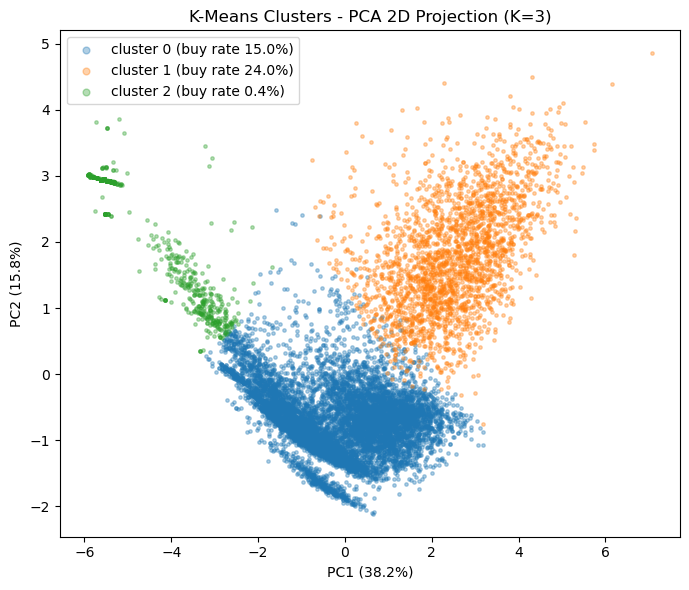

2개 주성분 누적 설명 분산: 54.0%


In [72]:
# PCA 2D 시각화
# 11차원 군집을 보려고 PCA로 2차원에 투영한다
# 군집은 11차원에서 했고 여기선 보기용으로만 2D로 누른다
pca = PCA(n_components = 2, random_state = RANDOM_STATE)
coords = pca.fit_transform(Z)   # coords: 각 세션의 2D 좌표

plt.figure(figsize = (7, 6))
for c in sorted(profile['cluster'].unique()):
    m = profile['cluster'] == c    # 군집 c에 속한 점만 골라 그린다
    plt.scatter(
        coords[m, 0],
        coords[m, 1],
        s = 6,
        alpha = 0.35,
        label = f'cluster {c} (buy rate {profile_table.loc[c, "purchase_rate"]:.1%})',
    )
plt.title(f'K-Means Clusters - PCA 2D Projection (K={BEST_K})')
# 축 라벨에 각 주성분이 설명하는 분산 비율을 표시(두 축 합이 클수록 2D가 원공간을 잘 대변)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.legend(markerscale = 2)
plt.tight_layout()
plt.show()

print(f'2개 주성분 누적 설명 분산: {pca.explained_variance_ratio_.sum():.1%}')

## 7. 군집 성능 평가 — 내부지표 · 외부지표 · 안정성

지도학습과 달리 군집화에는 단일 '정확도'가 없다. 군집 품질은 세 갈래로 나눠 평가한다.

- **내부지표(Internal)** — 정답 라벨 없이 군집 구조 자체의 품질(응집도·분리도)을 측정.
  실루엣, Davies–Bouldin, Calinski–Harabasz, inertia.
- **외부지표(External)** — 외부 라벨(여기서는 *학습에 쓰지 않은* `Revenue`)과 군집이 얼마나 일치하는지.
  ARI, NMI, homogeneity/completeness/V-measure, purity.
- **안정성(Stability)** — 초기화 시드·데이터 표본을 바꿔도 같은 군집이 재현되는지.
  군집 해가 우연한 산물이 아님을 보증한다.

세 지표를 함께 봐야 "군집이 뚜렷한가 / 의미 있는 신호와 연결되는가 / 재현 가능한가"를 모두 답할 수 있다.

### 지표 읽는 기준

군집화는 정답이 없어서 지표 하나로 잘라 말하기 어렵다. 그래서 성격이 다른 지표를 묶어서 본다.

- **군집이 잘 뭉치고 갈렸는지**: Silhouette(−1~1, 높을수록), Davies–Bouldin(낮을수록), Calinski–Harabasz(높을수록).
- **학습에 안 쓴 Revenue와 맞는지**: ARI·NMI(분할이 같은지)와 군집별 구매율 차이.
- **우연이 아닌지**: 시드·표본을 바꿔도 같은 군집이 나오는지(ARI).

실루엣은 대략 0.5 이상이면 무난, 0.25~0.5면 약하지만 분명한 구조로 본다. 사람 행동 데이터는 깔끔하게 안 나뉘는 편이라 0.3대도 충분히 의미 있다. 아래에서 지표를 하나씩 본다.

### 7.1 내부지표 — 군집 구조 자체의 품질

정답 없이 데이터 분포만으로 평가한다.

- **Silhouette**(−1~1, ↑좋음): 자기 군집 응집도 대비 이웃 군집과의 분리도.
- **Davies–Bouldin**(0~, ↓좋음): 군집 간 거리 대비 군집 내 산포. 0에 가까울수록 분리 우수.
- **Calinski–Harabasz**(↑좋음): 군집 간 분산 / 군집 내 분산 비. 클수록 잘 뭉치고 잘 떨어짐.
- **군집별 실루엣**: 어떤 유형이 가장 뚜렷한지 분해해서 본다.

In [73]:
# 성능평가 ①: 내부지표 (정답 없이 군집 구조 품질)
# 세 지표 모두 잘 뭉치고 잘 갈렸는지를 다르게 점수화한다
sil_full = silhouette_score(Z, cluster_labels)    # 실루엣: -1~1, 높을수록 또렷(전체로 계산)
db = davies_bouldin_score(Z, cluster_labels)      # Davies-Bouldin: 낮을수록 좋음(0이 이상)
ch = calinski_harabasz_score(Z, cluster_labels)   # Calinski-Harabasz: 높을수록 좋음

print('=== 내부지표 (정답 라벨 불필요) ===')
print(f'Silhouette (전체)       : {sil_full:.4f}   (-1~1, 높을수록 군집이 뚜렷)')
print(f'Davies-Bouldin Index    : {db:.4f}   (낮을수록 좋음)')
print(f'Calinski-Harabasz Index : {ch:,.1f}   (높을수록 좋음)')
print(f'Inertia (군집내 SSE)    : {kmeans.inertia_:,.1f}')

# 군집별 실루엣으로 어느 군집이 가장 또렷한지 본다
sil_samples = silhouette_samples(Z, cluster_labels)
per_cluster = (
    pd.DataFrame({
        'cluster': cluster_labels,
        'silhouette': sil_samples,
    })
    .groupby('cluster')['silhouette']
    .agg(['mean', 'size'])
    .round(4)
)
print('\n군집별 평균 실루엣')
print(per_cluster.to_string())

=== 내부지표 (정답 라벨 불필요) ===
Silhouette (전체)       : 0.3188   (-1~1, 높을수록 군집이 뚜렷)
Davies-Bouldin Index    : 1.1611   (낮을수록 좋음)
Calinski-Harabasz Index : 4,055.7   (높을수록 좋음)
Inertia (군집내 SSE)    : 80,645.6

군집별 평균 실루엣
           mean  size
cluster              
0        0.3040  8988
1        0.3055  2313
2        0.4998   904


**해석.**

실루엣 0.32, Davies–Bouldin 1.16, Calinski–Harabasz 4,056이다. 실루엣 0.3대는 약하지만 분명한 구조라는 뜻인데, 실제 사용자 행동은 깔끔한 덩어리로 안 나뉘고 연속적이라 이 정도면 타당하다. CH가 4천을 넘는 것도 군집 간 차이가 군집 내 차이보다 크다는 걸 뒷받침한다.

군집별로 보면 즉시 이탈 군집의 실루엣이 0.50으로 가장 또렷하다. 거의 바로 빠져나가는 세션이라 한쪽에 단단히 뭉친다. 반면 일반 탐색과 고관여는 0.30 정도로 낮은데, 둘이 관여 깊이로 이어져 있어 경계가 흐릿하기 때문이다.

### 7.2 외부지표 — 학습에 쓰지 않은 Revenue와의 정합성

군집은 `Revenue` 없이 만들었다. 사후에 실제 구매 라벨과 비교해 *외부 타당도*를 본다.

- **ARI / NMI**: 군집 분할과 `Revenue` 분할이 얼마나 일치하는가(우연 보정).
- **Homogeneity / Completeness / V-measure**: 한 군집이 한 클래스로 순수한가 / 한 클래스가 한 군집에 모이는가.
- **Purity**: 각 군집을 다수 클래스로 찍었을 때의 정확도(단, 불균형에 취약).

In [74]:
# 성능평가 ②: 외부지표 (학습에 안 쓴 Revenue와 비교)
# Revenue 없이 만든 군집이 실제 구매여부와 맞는지 사후 점검
ari = adjusted_rand_score(y, cluster_labels)
nmi = normalized_mutual_info_score(y, cluster_labels)
homo, comp, vme = homogeneity_completeness_v_measure(y, cluster_labels)

# 군집×구매여부 교차표, purity까지
ext_ct = pd.crosstab(profile['cluster'], profile['Revenue'])
purity = ext_ct.max(axis = 1).sum() / len(y)

print('=== 외부지표 (학습에 쓰지 않은 Revenue와 비교) ===')
print(f'Adjusted Rand Index (ARI) : {ari:.4f}')
print(f'Normalized MI (NMI)       : {nmi:.4f}')
print(f'Homogeneity               : {homo:.4f}')
print(f'Completeness              : {comp:.4f}')
print(f'V-measure                 : {vme:.4f}')
print(f'Purity                    : {purity:.4f}')
print('\n군집 x Revenue 분할표')
print(ext_ct.to_string())

# ARI/NMI가 낮아도 군집별 구매율 격차가 핵심이다
buy_rate = (ext_ct[1] / ext_ct.sum(axis = 1)).round(4)
print('\n군집별 실제 구매율')
print(buy_rate.to_string())

# 구매율 차이가 우연인지 카이제곱으로 확인
chi2, p_val, dof, _ = chi2_contingency(ext_ct)
print(f'\nchi-square 검정: chi2={chi2:.1f}, dof={dof}, p={p_val:.2e}')
print('→ p가 0에 가까우면 군집별 구매율 차이가 우연이 아니라 유의함')

# 효과크기는 Cramer's V로 본다
n_obs = ext_ct.values.sum()
cramers_v = np.sqrt(chi2 / (n_obs * (min(ext_ct.shape) - 1)))
print(f"Cramer's V = {cramers_v:.3f}  (효과크기: 0.1 작음 / 0.3 중간 / 0.5 큼)")

=== 외부지표 (학습에 쓰지 않은 Revenue와 비교) ===
Adjusted Rand Index (ARI) : 0.0104
Normalized MI (NMI)       : 0.0267
Homogeneity               : 0.0359
Completeness              : 0.0212
V-measure                 : 0.0267
Purity                    : 0.8437

군집 x Revenue 분할표
Revenue     0     1
cluster            
0        7638  1350
1        1759   554
2         900     4

군집별 실제 구매율
cluster
0    0.1502
1    0.2395
2    0.0044

chi-square 검정: chi2=282.1, dof=2, p=5.59e-62
→ p가 0에 가까우면 군집별 구매율 차이가 우연이 아니라 유의함
Cramer's V = 0.152  (효과크기: 0.1 작음 / 0.3 중간 / 0.5 큼)


**해석 — ARI/NMI가 낮은 건 실패가 아니라 정상이다.**

ARI 0.01, NMI 0.03으로 거의 0이다. 군집이 구매/비구매 2분할을 그대로 재현하지 않는다는 뜻인데, 애초에 군집은 Revenue 없이 행동만으로 만든 3개 유형이라 2분할과 맞을 이유가 없다. 구매자는 세 군집에 흩어져 있다.

여기서 처음 읽는 사람이 가장 헷갈리기 쉬운 부분은 `ARI/NMI가 낮으면 실패 아닌가?`이다. 이 분석의 목표는 구매 라벨을 복제하는 것이 아니라 행동 유형을 나누는 것이므로, 낮은 ARI/NMI는 구매 여부와 완전히 같은 분할이 아니라는 뜻에 가깝다.

Purity는 0.84로 높아 보이지만, 전체의 84%가 비구매라 다 비구매로 찍어도 나오는 수치라 의미가 없다.

그럼 무엇으로 검증하느냐면, 군집별 구매율 차이다. 0.4% → 15% → 24%로 뚜렷이 갈린다. 카이제곱 검정에서도 p값이 사실상 0이라 이 차이는 우연이 아니다. 다만 효과크기(Cramér's V)는 0.15로 작은~중간 수준이라, 군집이 구매율을 '옮기긴' 해도 구매 여부를 '결정'할 정도는 아니다. 다수인 일반 탐색 군집이 평균 구매율 근처에 있기 때문이다.

정리하면 ARI·NMI는 '정답 분할 복원'을 전제하는 지표라 세분화가 목적일 땐 잘 안 맞고, 이럴 땐 군집별 구매율 격차와 유의성으로 보는 게 맞다.

### 7.3 안정성 — 군집은 재현 가능한가

좋은 군집은 *우연*이 아니어야 한다. 두 가지로 흔들어 본다.

- **초기화 시드 안정성**: 시드 10종으로 다시 군집해 라벨링끼리의 쌍별 ARI를 본다(1에 가까울수록 같은 해).
- **데이터 표본 안정성**: 80% 부트스트랩 표본으로 군집해 전체 군집과의 ARI를 본다(표본을 흔들어도 같은 구조인가).

In [75]:
# 성능평가 ③: 안정성 (군집이 우연이 아니라 재현되는가)
# 시작점에 따라 흔들릴 수 있으니 두 가지로 흔들어 본다

# (1) 시드 10개로 각각 군집해 쌍마다 ARI를 잰다
SEEDS = [0, 1, 7, 21, 42, 100, 2024, 99, 13, 77]
seed_labels = [
    KMeans(
        n_clusters = BEST_K,
        random_state = s,
        n_init = 10,
    ).fit_predict(Z)
    for s in SEEDS
]
seed_ari = [adjusted_rand_score(a, b) for a, b in itertools.combinations(seed_labels, 2)]

# (2) 80% 표본으로 군집해 전체와 같은지 반복 확인
BOOTSTRAP_FRACTION = 0.8   # 매번 추출할 표본 비율
N_BOOTSTRAP = 20           # 반복 횟수
rng = np.random.default_rng(RANDOM_STATE)   # 재현 가능한 난수 생성기
boot_ari = []
for _ in range(N_BOOTSTRAP):
    # 비복원으로 80% 인덱스를 뽑아 그 부분만 다시 군집
    idx = rng.choice(len(Z), size = int(BOOTSTRAP_FRACTION * len(Z)), replace = False)
    bl = KMeans(
        n_clusters = BEST_K,
        random_state = RANDOM_STATE,
        n_init = 10,
    ).fit_predict(Z[idx])
    # 전체 군집과 80% 표본 군집이 같은지
    boot_ari.append(adjusted_rand_score(cluster_labels[idx], bl))

print('=== 안정성 (재현성) ===')
print(f'시드 10종 쌍별 ARI     : 평균 {np.mean(seed_ari):.4f}  (최소 {min(seed_ari):.4f})')
print(f'80% 부트스트랩 20회 ARI : 평균 {np.mean(boot_ari):.4f}  (최소 {min(boot_ari):.4f})')

=== 안정성 (재현성) ===
시드 10종 쌍별 ARI     : 평균 1.0000  (최소 1.0000)
80% 부트스트랩 20회 ARI : 평균 0.9975  (최소 0.9940)


**해석.**

시드를 10가지로 바꿔 봐도 쌍별 ARI가 1.000이다. 어떤 값으로 시작해도 똑같은 군집으로 수렴한다는 뜻이다. 데이터의 20%를 빼고 다시 군집해도 ARI가 0.998로 거의 그대로다. 특정 표본에 운 좋게 걸린 분할이 아니라 견고한 구조라는 얘기이고, 앞에서 K=3을 고른 게 우연이 아니었음을 뒷받침한다.

### 7.4 종합 — 군집 성능 한눈에

| 갈래 | 지표 | 값 | 판정 |
|---|---|---:|---|
| 내부 | Silhouette | ≈ 0.32 | 약하지만 분명한 구조(행동 데이터로는 타당) |
| 내부 | Davies–Bouldin | ≈ 1.16 | 보통 — 분리 양호 |
| 내부 | Calinski–Harabasz | ≈ 4,056 | 높음 — 군집 간 분리 우수 |
| 외부 | ARI / NMI | ≈ 0.01 / 0.03 | 낮음(=구매여부 2분할을 복제 안 함, **정상**) |
| 외부 | 군집별 구매율 격차 | 0.4% → 15% → 24% | **강함** — 세분화의 실질 타당도 |
| 외부 | 카이제곱 p값 | ≈ 5.6e-62 | 구매율 차이 매우 유의 |
| 안정성 | 시드 ARI | 1.000 | 초기화 불변 |
| 안정성 | 부트스트랩 ARI | ≈ 0.998 | 표본 견고 |

**결론**: 군집은 내부적으로 분명한 구조가 있고, 구매 여부를 그대로 복제하진 않지만 구매 성향을 강하게 갈라 주며, 시드·표본을 바꿔도 재현된다. K=3 세분화는 통계적으로 탄탄하고 해석도 잘 되는 결과다.

### 7.5 일반화 검증 — train/test로 과적합 점검

군집화엔 정답이 없어 지도학습식 과적합(train 정확도 ≫ test)이 그대로 적용되진 않지만,
**나눠서 일반화되는지**는 직접 확인할 수 있다.

1. 세션을 train/test로 분할(75/25, 구매율을 맞추려 `Revenue`로 층화).
2. **train으로만** 스케일러와 K-Means를 학습한다(누수 방지).
3. test는 `predict()`로 *가장 가까운 중심*에 배정(학습에 미사용).
4. test에서 ① 실루엣이 train과 비슷한지, ② **군집별 구매율 격차가 유지되는지**, ③ 군집 비중이 비슷한지 본다.

test에서도 구조와 구매율 단조성이 그대로면 일반화된 것(과적합 아님), 무너지면 과적합 신호다.

=== train/test 일반화 검증 (과적합 점검) ===
Silhouette : train=0.3193  test=0.3190  (차이 0.0003)
전체 구매율: train=0.1563  test=0.1563

군집별 구매율·비중 (train 구매율 오름차순)
              라벨  train_구매율  test_구매율  train_비중  test_비중
cluster 0  즉시 이탈     0.0043    0.0044     0.076    0.075
cluster 1  일반 탐색     0.1486    0.1579     0.738    0.730
cluster 2    고관여     0.2487    0.2084     0.187    0.195


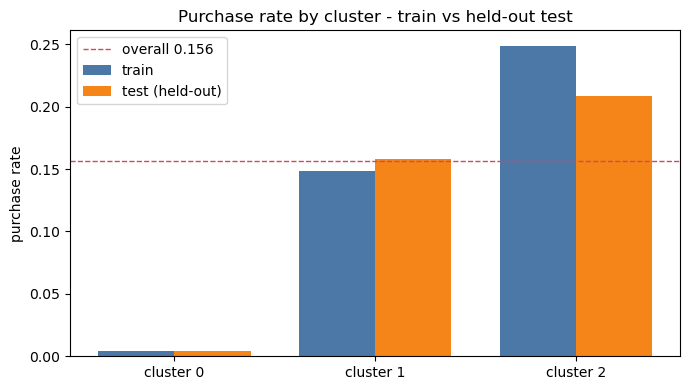

In [76]:
# 성능평가 ④: train/test 일반화 검증 (과적합 점검)
# train으로만 군집을 만들고 test에서도 같은 구조·구매율이 나오는지 본다
TEST_SIZE = 0.25   # 검증용으로 떼어 둘 비율(25%)

# 구매율 맞춰 층화 분할
Xtr_raw, Xte_raw, ytr, yte = train_test_split(
    X, y, test_size = TEST_SIZE, random_state = RANDOM_STATE, stratify = y)

# 누수 방지: 전처리도 train에만 fit, test는 변환만
Xtr_log = Xtr_raw.copy()
Xtr_log[LOG_COLS] = np.log1p(Xtr_log[LOG_COLS])

Xte_log = Xte_raw.copy()
Xte_log[LOG_COLS] = np.log1p(Xte_log[LOG_COLS])
sc_gen = StandardScaler().fit(Xtr_log)
Z_tr, Z_te = sc_gen.transform(Xtr_log), sc_gen.transform(Xte_log)

# train으로 학습, test는 가장 가까운 중심에 배정
km_gen = KMeans(
    n_clusters = BEST_K,
    random_state = RANDOM_STATE,
    n_init = 10,
).fit(Z_tr)
lab_tr, lab_te = km_gen.labels_, km_gen.predict(Z_te)

# 비교1: 실루엣이 train과 test에서 비슷한가
sil_tr = silhouette_score(Z_tr, lab_tr)
sil_te = silhouette_score(Z_te, lab_te)

# 비교2: 군집별 구매율·비중이 train≈test인가
def _rate_size(lab, yv):
    """군집별 (구매율 평균, 세션 수)를 한 번에 반환하는 작은 도우미."""
    g = (
        pd.DataFrame({
            'c': lab,
            'y': yv.values,
        })
        .groupby('c')['y']
    )
    return g.mean(), g.size()
rt_tr, sz_tr = _rate_size(lab_tr, ytr)
rt_te, sz_te = _rate_size(lab_te, yte)
order = rt_tr.sort_values().index   # train 구매율 오름차순 = 즉시이탈 → 일반탐색 → 고관여

gen = pd.DataFrame({
    '라벨': ['즉시 이탈', '일반 탐색', '고관여'],
    'train_구매율': rt_tr[order].round(4).values,
    'test_구매율':  rt_te[order].round(4).values,
    'train_비중':   (sz_tr[order] / sz_tr.sum()).round(3).values,
    'test_비중':    (sz_te[order] / sz_te.sum()).round(3).values,
}, index = [f'cluster {c}' for c in order])

print('=== train/test 일반화 검증 (과적합 점검) ===')
print(f'Silhouette : train={sil_tr:.4f}  test={sil_te:.4f}  (차이 {abs(sil_tr - sil_te):.4f})')
print(f'전체 구매율: train={ytr.mean():.4f}  test={yte.mean():.4f}')
print('\n군집별 구매율·비중 (train 구매율 오름차순)')
print(gen.to_string())

# 군집별 구매율을 train vs test 막대로 비교
xpos = np.arange(BEST_K)
bar_w = 0.38   # 막대 두께(두 막대가 겹치지 않게)
plt.figure(figsize = (7, 4))
plt.bar(
    xpos - bar_w / 2,
    rt_tr[order].values,
    bar_w,
    label = 'train',
    color = '#4c78a8',
)
plt.bar(
    xpos + bar_w / 2,
    rt_te[order].values,
    bar_w,
    label = 'test (held-out)',
    color = '#f58518',
)
plt.axhline(
    y.mean(),
    color = '#d1495b',
    ls = '--',
    lw = 1,
    label = f'overall {y.mean():.3f}',
)
plt.xticks(xpos, [f'cluster {c}' for c in order])
plt.title('Purchase rate by cluster - train vs held-out test')
plt.ylabel('purchase rate')
plt.legend()
plt.tight_layout()
plt.show()

**해석 — 과적합 아니다.**

train으로만 군집을 만들고 test를 거기에 배정해도 실루엣이 0.319로 train과 거의 같다(차이 0.0003). 군집 경계가 특정 표본에 끼워 맞춰진 게 아니라는 직접 증거다. 군집별 구매율도 test에서 그대로 재현된다(즉시 이탈 0.4%, 일반 탐색 약 15%, 고관여 약 21~25%). 군집 비중도 train과 test가 거의 같다. 새 데이터를 넣어도 같은 구조가 나온다는 뜻이라 과적합이 아니다.

## 8. (부록) K-Means 수렴 중간과정 — Lloyd 반복 시각화

K-Means가 *어떻게* 군집을 찾아가는지 단계별로 본다. 알고리즘은 두 단계를 번갈아 반복한다(Lloyd 알고리즘).

1. **할당(assign)**: 각 점을 가장 가까운 중심에 배정.
2. **갱신(update)**: 각 군집의 평균 위치로 중심을 이동.

K-Means 기본 초기화(**k-means++**, sklearn 기본값)에서 출발해 1 iteration씩 진행 상황을 기록한다.
군집은 *실제 분석과 동일하게 11차원 원공간에서* 수행하고, 한 번만 학습한 **고정 PCA**로 매 프레임을
같은 2D 평면에 투영해 서로 비교할 수 있게 한다. (프레임마다 군집 번호가 바뀌어 색이 섞이지 않도록,
각 프레임의 군집을 *최종 중심*에 매칭해 색을 통일했다.) 데이터가 작아 전 과정이 1~2초면 끝난다.

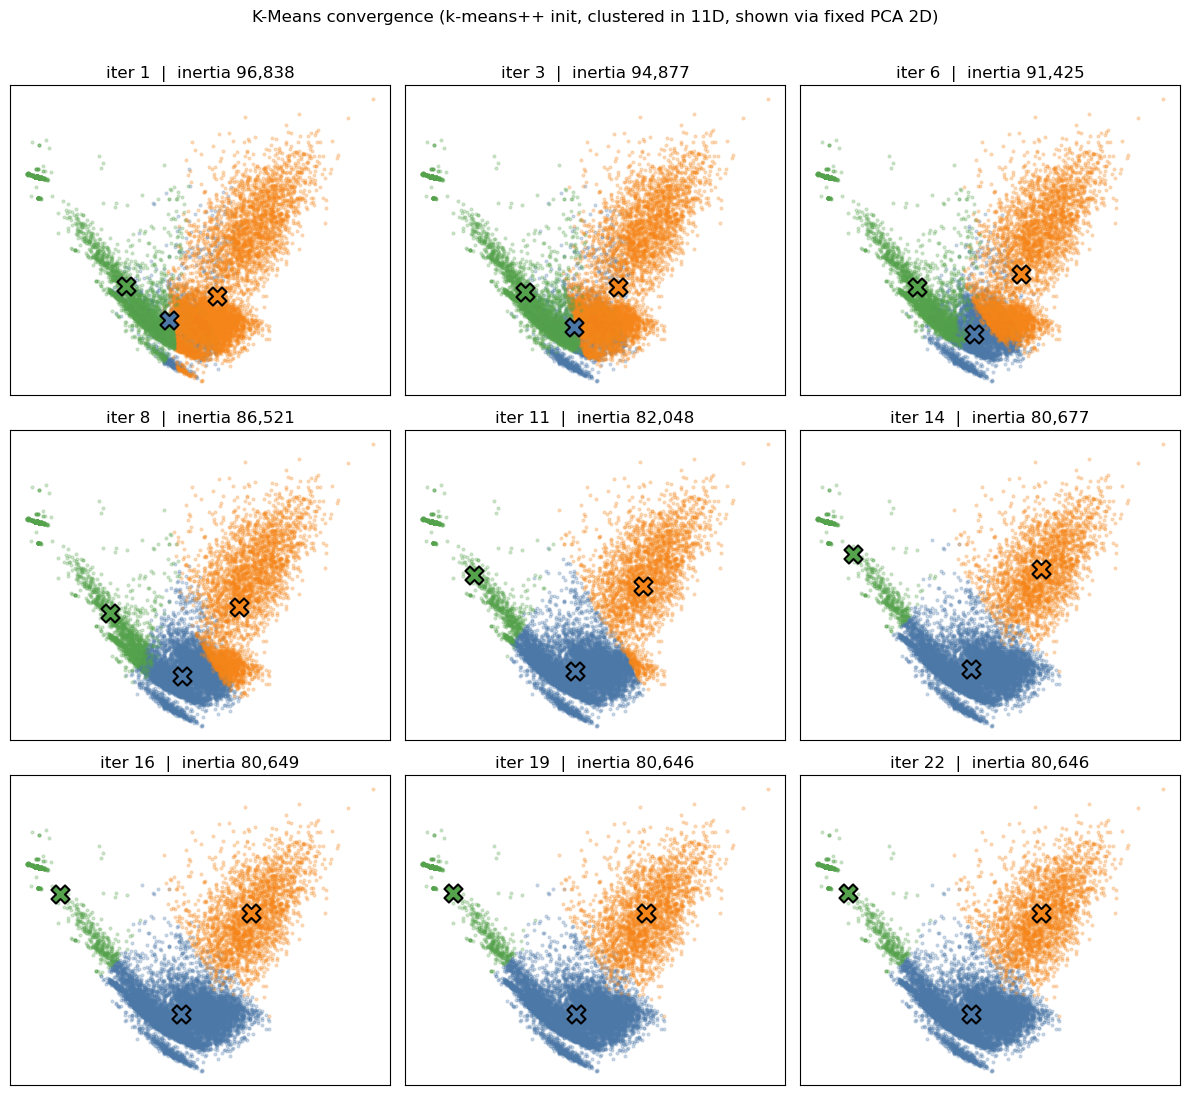

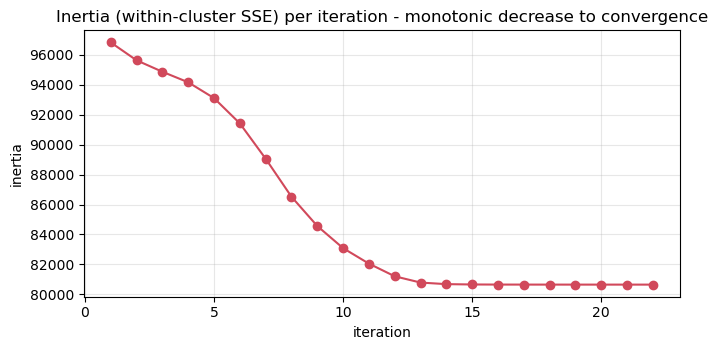

총 22 iteration 만에 수렴 (inertia 96,838 -> 80,646, 3장 n_init=10 결과와 동일)


In [77]:
# (부록) K-Means 수렴 과정 시각화
# K-Means가 군집을 찾아가는 과정을 단계별로 본다
# max_iter=1로 한 스텝씩 돌려 중심 이동을 기록
# 6장에서 fit한 PCA·좌표를 그대로 재사용

# 첫 스텝은 k-means++, 이후엔 직전 중심을 넣어 이어붙인다
MAX_ITERS = 30   # 안전 상한(보통 그 전에 수렴)
centers = 'k-means++'
frames, prev = [], None
for it in range(1, MAX_ITERS + 1):
    km = KMeans(
        n_clusters = BEST_K,
        init = centers,
        n_init = 1,
        max_iter = 1,
        random_state = RANDOM_STATE,
    ).fit(Z)
    frames.append({
        'it': it,
        'labels': km.labels_.copy(),
        'centers': km.cluster_centers_.copy(),
        'inertia': km.inertia_,
    })
    if prev is not None and np.allclose(prev, km.cluster_centers_):   # 중심이 안 움직이면 수렴
        break
    prev = centers = km.cluster_centers_

# 반복마다 군집 번호가 뒤바뀌어 색이 깜빡일 수 있다
# 최종 중심에 1:1 매칭해 색을 통일
final_centers = frames[-1]['centers']
def align(fr):
    # 프레임 중심과 최종 중심 사이 거리표를 만들고, 총거리가 최소가 되게 짝짓는다.
    cost = np.linalg.norm(
        fr['centers'][:, None, :] - final_centers[None, :, :],
        axis = 2,
    )
    row, col = linear_sum_assignment(cost)
    perm = np.empty(BEST_K, dtype = int)
    perm[row] = col
    return perm[fr['labels']], perm   # (색 통일된 라벨, 군집번호 변환표)

# 프레임 많으면 9장만 골라 3x3로 보여준다
MAX_PANELS = 9
if len(frames) <= MAX_PANELS:
    show = frames
else:
    idx = np.unique(np.linspace(0, len(frames) - 1, MAX_PANELS).astype(int))
    show = [frames[i] for i in idx]

COL = ['#4c78a8', '#f58518', '#54a24b']   # 군집 0/1/2 색
ncol = 3
nrow = int(np.ceil(len(show) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize = (12, 3.6 * nrow))
for ax, fr in zip(axes.ravel(), show):
    al, perm = align(fr)
    for c in range(BEST_K):                 # 점: 군집별 색으로 흩뿌리기
        m = al == c
        ax.scatter(
            coords[m, 0],
            coords[m, 1],
            s = 4,
            alpha = 0.25,
            color = COL[c],
        )
    cen2 = pca.transform(fr['centers'])     # 중심(11D)을 같은 PCA로 2D에 투영
    for k in range(BEST_K):
        ax.scatter(
            cen2[k, 0],
            cen2[k, 1],
            color = COL[perm[k]],
            marker = 'X',
            s = 170,
            edgecolor = 'black',
            linewidth = 1.5,
            zorder = 5,
        )
    ax.set_title(f"iter {fr['it']}  |  inertia {fr['inertia']:,.0f}")
    ax.set_xticks([])
    ax.set_yticks([])
for ax in axes.ravel()[len(show):]:         # 남는 빈 칸 숨기기
    ax.axis('off')
fig.suptitle('K-Means convergence (k-means++ init, clustered in 11D, shown via fixed PCA 2D)', y = 1.01)
plt.tight_layout()
plt.show()

# inertia가 줄다 평평해지는 수렴 곡선
plt.figure(figsize = (7, 3.6))
its = [f['it'] for f in frames]
ins = [f['inertia'] for f in frames]
plt.plot(its, ins, marker = 'o', color = '#d1495b')
plt.title('Inertia (within-cluster SSE) per iteration - monotonic decrease to convergence')
plt.xlabel('iteration')
plt.ylabel('inertia')
plt.grid(alpha = 0.3)
plt.tight_layout()
plt.show()

print(f'총 {len(frames)} iteration 만에 수렴 '
      f'(inertia {frames[0]["inertia"]:,.0f} -> {frames[-1]["inertia"]:,.0f}, '
      f'3장 n_init=10 결과와 동일)')

**해석.**

중심(✕)이 매 반복마다 군집 평균으로 옮겨가고, 점들의 색이 점점 안정된다. 처음 몇 번에서 크게 움직인 뒤 미세 조정으로 바뀐다. inertia 곡선은 가파르게 떨어지다 평평해지는데, 그 지점이 수렴이다(K-Means는 매 반복마다 inertia가 줄기만 한다). 20번쯤 반복하면 3장에서 얻은 것과 같은 inertia로 수렴하면서, 즉시 이탈·일반 탐색·고관여 세 군집을 그대로 다시 찾아낸다.

### 결론

군집화는 행동 변수만으로 방문자를 즉시이탈·일반탐색·고관여 세 유형으로 나눴고, 학습에 안 쓴 실제 구매율이 0.4% → 15% → 24%로 올라 군집이 구매 성향과 잘 맞는다는 걸 확인했다. 이건 DT·RF·KNN이 공통으로 상품 탐색 시간·페이지 수에 크게 의존한 것과 같은 신호다. 결국 예측 모델이 중요하게 본 축이 곧 군집을 가르는 축이었다.

실무로 옮기면 고관여 군집은 리타게팅·혜택을 집중하고, 일반 탐색 군집은 전환을 유도하며(가장 다수라 개선 여지가 크다), 즉시 이탈 군집은 랜딩·유입 품질을 손보는 식으로 나눠 대응할 수 있다.